In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from prnn.utils.predictiveNet import PredictiveNet
from prnn.utils.agent import create_agent
from prnn.utils.data import create_dataloader
from prnn.utils.env import make_env
from prnn.utils.figures import TrainingFigure
from prnn.utils.figures import SpontTrajectoryFigure
from prnn.analysis.OfflineTrajectoryAnalysis import OfflineTrajectoryAnalysis
import argparse
from tqdm import tqdm

#TODO: get rid of these dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import pandas as pd

wandb not installed, will not log to wandb
<class 'prnn.utils.thetaRNN.RNNCell'>
in thetaRNN args (3, 7)
in thetaRNN kwargs {}
basecell kwargs {}


In [3]:
import prnn.utils.predictiveNet as pNet
from prnn.utils.env import make_env
from prnn.analysis.TuningCurveAnalysis import TuningCurveAnalysis

from prnn.utils.predictiveNet import PredictiveNet
from prnn.utils.agent import RandomActionAgent
from prnn.analysis.SpatialTuningAnalysis import SpatialTuningAnalysis
from prnn.utils.thetaRNN import RNNCell, LayerNormRNNCell, DivNormRNNCell, AdaptingLayerNormRNNCell, AdaptingRNNCell
from prnn.utils.Architectures import NextStepRNN, MaskedRNN, RolloutRNN, pRNN, pRNN_th, pRNN_multimodal
import numpy as np

In [4]:
env_str="LRoom-18x18-v0"
lr=2e-3
numepochs=5
numtrials=10
envPackage='farama-minigrid'
batchsize=16
sparsity=0.5
bias_lr=0.1
eg_lr=2e-3
eg_weight_decay=1e-8
dataNtraj = 10
seqdur = 500
numworkers= 1
datadir = 'Data'
actenc='SpeedHD'
k=5 
hidden_sizes=[10, 100, 500, 800, 1000, 10000]
pRNNtype='Masked'
agent = 'RandomActionAgent'
savename = pRNNtype + '-s'
figfolder = 'nets/test/trainfigs/'+savename
analysisfolder = 'nets/test/analysis/'+savename
cell = "DivNormRNNCell"
k_divs = [0.01, 0.05, 0.1, 0.5, 1]
sigmas = [0.01, 0.05, 0.1, 0.5, 1]
results = []

/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.grid to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.grid` for environment variables or `env.get_wrapper_attr('grid')` that 

In [ ]:
k_div = 3
sigma = 5
mean_std_ratio = 2
hidden_size = 800
net = pNet.PredictiveNet(env=env, pRNNtype=pRNNtype,
                                hidden_size=hidden_size,
                                numepochs=numepochs,
                                numtrials=numtrials,
                                cell=DivNormRNNCell,
                                eg_lr=eg_lr,
                                eg_weight_decay=eg_weight_decay,
                                k_div=k_div,
                                sigma=sigma,
                                mean_std_ratio = mean_std_ratio)



pRNN init {'numepochs': 5, 'numtrials': 10, 'k_div': 3, 'sigma': 5, 'mean_std_ratio': 2}
right before thetaRNNLayer init {'numepochs': 5, 'numtrials': 10, 'k_div': 3, 'sigma': 5, 'mean_std_ratio': 2}
<class 'prnn.utils.thetaRNN.DivNormRNNCell'>
in thetaRNN args (158, 800)
in thetaRNN kwargs {'mu': 0.0, 'sig': 1, 'numepochs': 5, 'numtrials': 10, 'k_div': 3, 'sigma': 5, 'mean_std_ratio': 2}
divnorm kwargs {'mu': 0.0, 'sig': 1, 'numepochs': 5, 'numtrials': 10, 'mean_std_ratio': 2}
basecell kwargs {'mu': 0.0, 'sig': 1, 'numepochs': 5, 'numtrials': 10, 'mean_std_ratio': 2}
sigma 5 k_div 3


In [ ]:


# Calculate total combinations
total_combos = len(hidden_sizes) * len(k_divs) * len(sigmas)
combo_counter = 0

for h_idx, hidden_size in enumerate(hidden_sizes):
    for i, k_div in enumerate(k_divs):
        for j, sigma in enumerate(sigmas):
            combo_counter += 1
            print(f"\n{'='*60}")
            print(f"Running hidden_size={hidden_size}, k_div={k_div}, sigma={sigma}")
            print(f"Progress: {combo_counter}/{total_combos}")
            print(f"{'='*60}")
            
           
            
            obs, act, state, render = net.collectObservationSequence(env, agent, discretize=True, tsteps=50)
            obs_pred, obs_next, h = net.predict(obs, act, fullRNNstate=False)

            # Calculate statistics
            h_flat = h.detach().cpu().numpy().flatten()
            h_mean = np.mean(h_flat)
            h_std = np.std(h_flat)
            h_min = np.min(h_flat)
            h_max = np.max(h_flat)
            
            # Store results
            results.append({
                'hidden_size': hidden_size,
                'k_div': k_div,
                'sigma': sigma,
                'mean': h_mean,
                'std': h_std,
                'min': h_min,
                'max': h_max,
                'shape': str(h.shape)
            })
            
            # Print current combo
            print(f"  Shape: {h.shape}")
            print(f"  Mean:  {h_mean:.6f}")
            print(f"  Std:   {h_std:.6f}")
            print(f"  Range: [{h_min:.6f}, {h_max:.6f}]")
            
            # Optional: plot
            # plt.figure(figsize=(10, 4))
            # plt.plot(h.detach().cpu().numpy().squeeze())
            # plt.title(f'h_size={hidden_size}, k_div={k_div}, sigma={sigma}')
            # plt.xlabel('Time')
            # plt.ylabel('Hidden state')
            # plt.tight_layout()
            # plt.show()

# Create DataFrame for easy viewing
df_results = pd.DataFrame(results)

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE - ALL COMBINATIONS")
print("="*80)
print(df_results.to_string(index=False))

# Print pivot tables for each hidden_size
for hidden_size in hidden_sizes:
    df_hs = df_results[df_results['hidden_size'] == hidden_size]
    
    print("\n" + "="*80)
    print(f"MEAN VALUES (k_div × sigma) | hidden_size = {hidden_size}")
    print("="*80)
    pivot_mean = df_hs.pivot(index='k_div', columns='sigma', values='mean')
    print(pivot_mean.to_string(float_format='%.6f'))
    
    print("\n" + "="*80)
    print(f"STD VALUES (k_div × sigma) | hidden_size = {hidden_size}")
    print("="*80)
    pivot_std = df_hs.pivot(index='k_div', columns='sigma', values='std')
    print(pivot_std.to_string(float_format='%.6f'))

# Save to CSV
df_results.to_csv('divnorm_parameter_sweep.csv', index=False)
print(f"\n\nResults saved to: divnorm_parameter_sweep.csv")

# Optional: Create summary statistics across hidden_sizes
print("\n" + "="*80)
print("SUMMARY: Effect of hidden_size (averaged across k_div and sigma)")
print("="*80)
summary_by_hidden = df_results.groupby('hidden_size').agg({
    'mean': ['mean', 'std', 'min', 'max'],
    'std': ['mean', 'std', 'min', 'max']
}).round(6)
print(summary_by_hidden)

In [6]:
rnn_types = ['NextStep', 'Masked', 'Rollout','multRNN_5win_i01_o01']
for rnn in rnn_types:
    print(rnn)
    net = pNet.PredictiveNet(env, pRNNtype=rnn)
    cell_types = [RNNCell, AdaptingLayerNormRNNCell, LayerNormRNNCell, DivNormRNNCell, AdaptingRNNCell]
    for i in range(len(cell_types)):
        cell_type = cell_types[i]
        print(i)
        net = pNet.PredictiveNet(env, pRNNtype=rnn, cell=cell_type)
        
            

NextStep
{}
layernorm
normal base
0
{'cell': <class 'prnn.utils.thetaRNN.RNNCell'>}
normal base
1
{'cell': <class 'prnn.utils.thetaRNN.AdaptingLayerNormRNNCell'>}
Adapting Layernorm
layernorm
Adapting
normal base
hello
2
{'cell': <class 'prnn.utils.thetaRNN.LayerNormRNNCell'>}
layernorm
normal base
3
{'cell': <class 'prnn.utils.thetaRNN.DivNormRNNCell'>}
normal base
divnorm
4
{'cell': <class 'prnn.utils.thetaRNN.AdaptingRNNCell'>}
Adapting
normal base
Masked
{}
layernorm
normal base
0
{'cell': <class 'prnn.utils.thetaRNN.RNNCell'>}
normal base
1
{'cell': <class 'prnn.utils.thetaRNN.AdaptingLayerNormRNNCell'>}
Adapting Layernorm
layernorm
Adapting
normal base
hello
2
{'cell': <class 'prnn.utils.thetaRNN.LayerNormRNNCell'>}
layernorm
normal base
3
{'cell': <class 'prnn.utils.thetaRNN.DivNormRNNCell'>}
normal base
divnorm
4
{'cell': <class 'prnn.utils.thetaRNN.AdaptingRNNCell'>}
Adapting
normal base
Rollout
{}
layernorm
normal base
0
{'cell': <class 'prnn.utils.thetaRNN.RNNCell'>}
normal 

/gpfs/radev/project/saxena/mc3863/pRNN/prnn/utils/predictiveNet.py:521: DeprecationWarning: invalid escape sequence \{
  f"loss: {steploss:>.2}, sparsity: {sparsity:>.2}, meanrate: {meanrate:>.2} [{bb:>5d}\{num_trials:>5d}]"
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/utils/predictiveNet.py:552: DeprecationWarning: invalid escape sequence \{
  f"loss: {steploss:>.2}, sparsity: {sparsity:>.2}, meanrate: {meanrate:>.2} [{bb:>5d}\{num_trials:>5d}]"


IndexError: invalid index to scalar variable.

/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.grid to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.grid` for environment variables or `env.get_wrapper_attr('grid')` that 

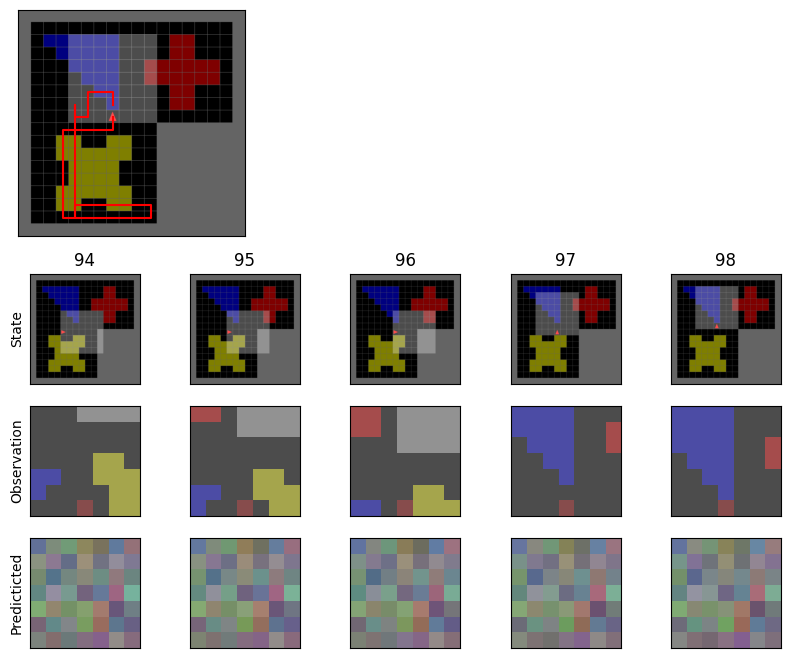

Found existing data, will generate more data if needed
Dataloader created with 10 trajectories, sequence length 500
Training Baseline
Training pRNN on cuda...
loss: 0.027, sparsity: 0.55, meanrate: 0.35 [    0\    1]
Epoch Complete. Back to the cpu
Calculating INITIAL Spatial Representation...


/gpfs/radev/project/saxena/mc3863/pRNN/prnn/utils/predictiveNet.py:520: DeprecationWarning: invalid escape sequence \{
  f"loss: {steploss:>.2}, sparsity: {sparsity:>.2}, meanrate: {meanrate:>.2} [{bb:>5d}\{num_trials:>5d}]"
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/utils/predictiveNet.py:551: DeprecationWarning: invalid escape sequence \{
  f"loss: {steploss:>.2}, sparsity: {sparsity:>.2}, meanrate: {meanrate:>.2} [{bb:>5d}\{num_trials:>5d}]"


KeyboardInterrupt: 

In [ ]:

net = pNet.PredictiveNet(env=env)
 #allows values in trainArgs to be accessible 

    #net.seed = seed
    #net.trainArgs = args
net.plotSampleTrajectory(env,agent,
                                    savename=savename+'exTrajectory_untrained',
                                    savefolder=figfolder)
#net.savefolder = savefolder
#net.savename = savename



    # Separate Data Loader should be created for every environment
create_dataloader(env, agent, dataNtraj, seqdur,
                    datadir, generate=True,
                #   tmp_folder=os.path.expandvars('${SLURM_TMPDIR}'), # This should stay commented out unless running on MILA cluster
                    batch_size=batchsize, 
                    num_workers=numworkers)
net.useDataLoader = True


#%% Training Epoch
#Consider these as "trainingparameters" class/dictionary
numepochs = numepochs
sequence_duration = seqdur
num_trials = numtrials

batchsize = batchsize


net.trainingCompleted = False
if net.numTrainingTrials == -1:
    #Calculate initial spatial metrics etc
    print('Training Baseline')
    net.useDataLoader = False
    net.trainingEpoch(env, agent,
                            sequence_duration=sequence_duration,
                            num_trials=1)
    net.useDataLoader = True
    print('Calculating INITIAL Spatial Representation...')
    place_fields, SI, decoder = net.calculateSpatialRepresentation(env,agent,
                                                  trainDecoder=True,saveTrainingData=True,
                                                  bitsec= False,
                                                  calculatesRSA = True, sleepstd=0.03)
    net.plotTuningCurvePanel(savename=savename,savefolder=figfolder)
    print('Calculating INITIAL Decoding Performance...')
    net.calculateDecodingPerformance(env,agent,decoder,
                                                savename=savename, savefolder=figfolder,
                                                saveTrainingData=True)
    #net.plotDelayDist(env, agent, decoder)

if hasattr(net, 'numTrainingEpochs') is False:
    net.numTrainingEpochs = int(net.numTrainingTrials/num_trials)

progress = tqdm(total=numepochs, desc="Training Epochs") #tdqm status bar

while net.numTrainingEpochs<numepochs: #run through all epochs
    print(f'Training Epoch {net.numTrainingEpochs}')
    net.trainingEpoch(env, agent,
                            sequence_duration=sequence_duration,
                            num_trials=num_trials)
    print('Calculating Spatial Representation...')
    place_fields, SI, decoder = net.calculateSpatialRepresentation(env,agent,
                                                 trainDecoder=True, trainHDDecoder = True,
                                                 saveTrainingData=True, bitsec= False,
                                                 calculatesRSA = True, sleepstd=0.03)
    print('Calculating Decoding Performance...')
    net.calculateDecodingPerformance(env,agent,decoder,
                                                savename=savename, savefolder=figfolder,
                                                saveTrainingData=True)
    net.plotLearningCurve(savename=savename,savefolder=figfolder,
                                    incDecode=True)
    net.plotTuningCurvePanel(savename=savename,savefolder=figfolder)
    plt.show()
    plt.close('all')
    net.saveNet("nets/test/"+savename)

    progress.update(1)

progress.close()

net.trainingCompleted = True
TrainingFigure(net,savename=savename,savefolder=figfolder)



(array([  1.,   6.,  19.,  50.,  84., 115., 179., 210., 263., 286., 357.,
        344., 449., 399., 397., 435., 392., 432., 410., 409., 419., 433.,
        377., 357., 356., 329., 317., 306., 306., 270., 261., 285., 243.,
        242., 248., 256., 196., 199., 196., 177., 188., 166., 163., 167.,
        160., 136., 136., 137., 118., 127., 108., 122.,  95., 102.,  92.,
        102., 100.,  83.,  93.,  81.,  77.,  75.,  77.,  88.,  71.,  71.,
         70.,  45.,  50.,  46.,  42.,  34.,  46.,  46.,  33.,  34.,  35.,
         43.,  32.,  37.,  34.,  26.,  32.,  31.,  34.,  32.,  37.,  16.,
         31.,  25.,  30.,  21.,  27.,  23.,  20.,  24.,  23.,  18.,  27.,
         15.,  18.,  19.,  12.,  15.,  20.,  19.,  22.,  12.,  14.,  10.,
         12.,  19.,   5.,  15.,  14.,  15.,  16.,   6.,  14.,  10.,  11.,
         11.,   9.,   9.,  15.,   9.,  13.,  10.,   8.,   7.,   3.,   6.,
          8.,   9.,   2.,   8.,   6.,   7.,   8.,   4.,   8.,   4.,   5.,
          7.,  10.,   8.,   6.,   8., 

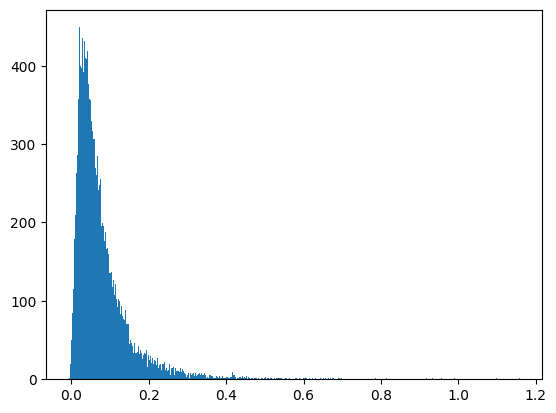

In [6]:
plt.hist(net.pRNN.W_in.detach().cpu().numpy().flatten(), bins = 500)

In [7]:


# net = pNet.PredictiveNet(env=env, pRNNtype=pRNNtype,
#                          hidden_size=hidden_size,
#                          batchsize=batchsize,
#                         #  eg_lr=eg_lr, 
#                         #  g_weight_decay=eg_weight_decay,
#                          k=k)    

In [6]:
%pwd

'/gpfs/radev/project/saxena/mc3863/pRNN/test'

In [6]:
net.trainArgs

namespace(env=<prnn.utils.Shell.FaramaMinigridShell at 0x14b846fb1d30>,
          agent='RandomActionAgent',
          envPackage='farama-minigrid',
          pRNNtype='Masked',
          cell='DivNormRNNCell',
          savefolder='div_norm_test2/',
          loadfolder='',
          numepochs=50,
          seqdur=500,
          numtrials=1024,
          hidden_size=800,
          contin=False,
          load_env=-1,
          seed=8,
          lr=0.002,
          weight_decay=0.003,
          neuralTimescale=2,
          dropout=0.15,
          noisemean=0,
          noisestd=0.03,
          trainBias=True,
          namext='',
          actenc='SpeedHD',
          saveTrainData=True,
          withDataLoader=True,
          datadir='Data',
          dataNtraj=10240,
          batchsize=16,
          numworkers=1,
          sparsity=0.5,
          use_FF=False,
          mask_actions=False,
          actOffset=0,
          k=5,
          rollout_action='full',
          continuousThe

In [28]:
net.pRNN.rnn.cell.divnorm.k_div

1

In [ ]:
dir(net.pRNN.rnn.cell.divnorm.k_div)

['__abs__',
 '__add__',
 '__and__',
 '__bool__',
 '__ceil__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floor__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getnewargs__',
 '__gt__',
 '__hash__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__le__',
 '__lshift__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rfloordiv__',
 '__rlshift__',
 '__rmod__',
 '__rmul__',
 '__ror__',
 '__round__',
 '__rpow__',
 '__rrshift__',
 '__rshift__',
 '__rsub__',
 '__rtruediv__',
 '__rxor__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__trunc__',
 '__xor__',
 'as_integer_ratio',
 'bit_length',
 'conjugate',
 'denominator',
 'from_bytes',
 'imag',
 'numerator',
 'real',
 'to_bytes']

Net Loaded from pathname
Net Loaded from pathname


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


Training Decoder on cuda...
loss: 5.982388 [    0\ 5000]
loss: 2.877471 [  500\ 5000]
loss: 2.447273 [ 1000\ 5000]
loss: 2.237129 [ 1500\ 5000]
loss: 2.101608 [ 2000\ 5000]
loss: 1.992613 [ 2500\ 5000]
loss: 1.926751 [ 3000\ 5000]
loss: 1.865779 [ 3500\ 5000]
loss: 1.814317 [ 4000\ 5000]
loss: 1.791278 [ 4500\ 5000]
loss: 1.769788 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


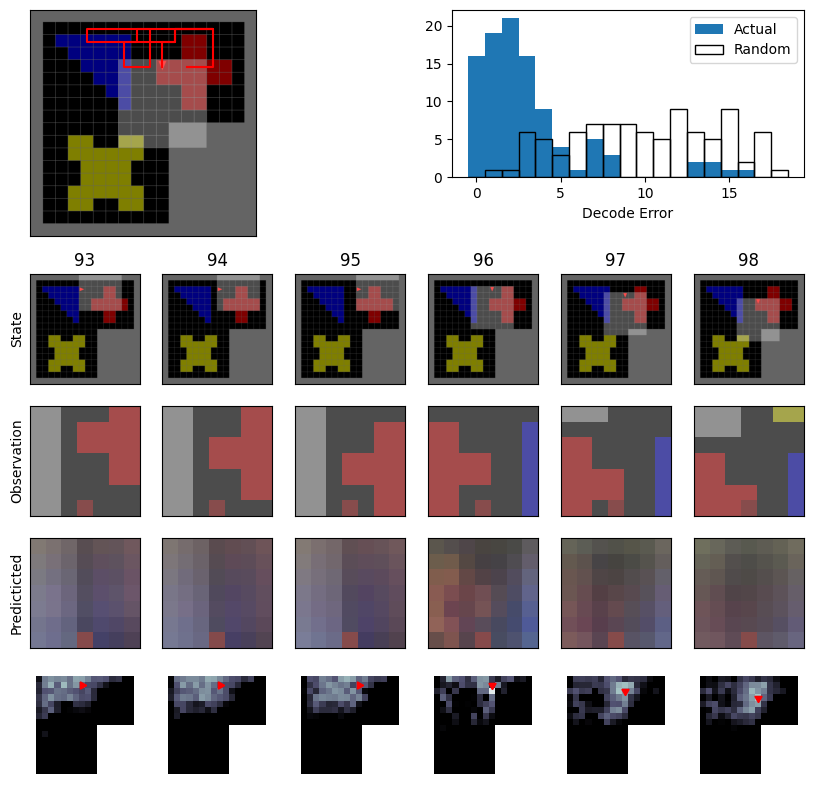

/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:378: RuntimeWarning: invalid value encountered in divide
  fxfr = fx / fr
/gpfs/radev/home/mc386

Training Decoder on cuda...
loss: 5.787053 [    0\ 5000]
loss: 0.167015 [  500\ 5000]
loss: 0.079797 [ 1000\ 5000]
loss: 0.051615 [ 1500\ 5000]
loss: 0.037551 [ 2000\ 5000]
loss: 0.028826 [ 2500\ 5000]
loss: 0.022460 [ 3000\ 5000]
loss: 0.018338 [ 3500\ 5000]
loss: 0.014632 [ 4000\ 5000]
loss: 0.012005 [ 4500\ 5000]
loss: 0.009826 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


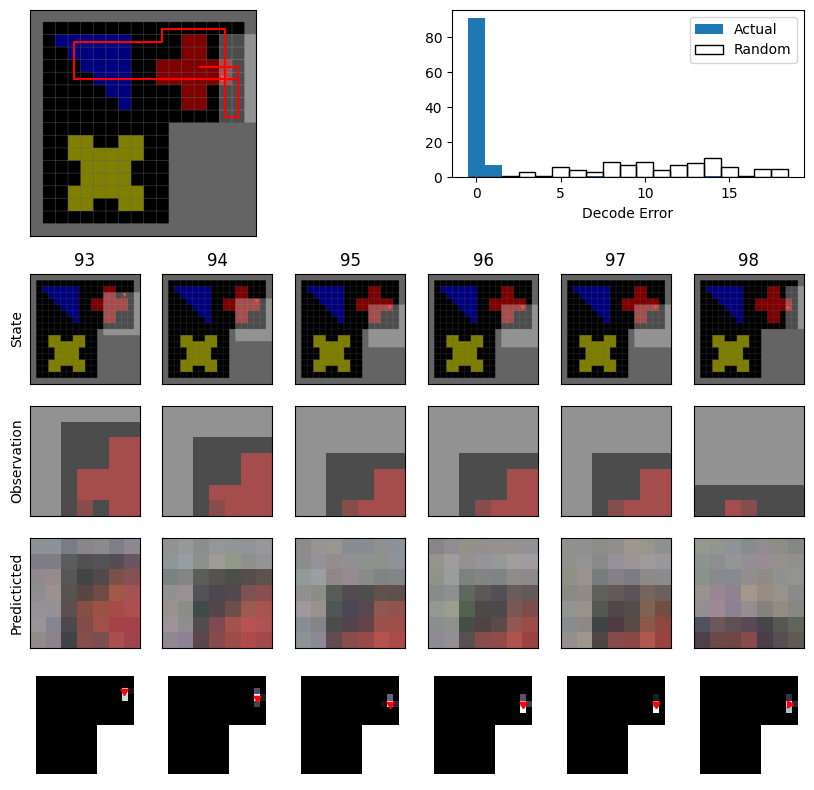

In [9]:

divnorm_net = pNet.PredictiveNet.loadNet(r'div_norm_test2/Masked--s8')
norm_net = pNet.PredictiveNet.loadNet(r'norm_test2/Masked--s8')
env = divnorm_net.EnvLibrary[0]
agentname = 'RandomActionAgent'
action_probability = np.array([0.15,0.15,0.6,0.1,0,0,0]) # R , L , F, Stop , random other actions no one uses
agent = RandomActionAgent(env.action_space,action_probability)
dv_place_fields, dv_SI, dv_decoder = divnorm_net.calculateSpatialRepresentation(env,agent,
                                             trainDecoder=True)
divnorm_net.calculateDecodingPerformance(env,agent,dv_decoder,
                                            savename=None, savefolder=None,
                                          trajectoryWindow=100,
                                          timesteps=100)
place_fields, SI, decoder = norm_net.calculateSpatialRepresentation(env,agent,
                                             trainDecoder=True)
norm_net.calculateDecodingPerformance(env,agent,decoder,
                                            savename=None, savefolder=None,
                                          trajectoryWindow=100,
                                          timesteps=100)

Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/representationalGeometryAnalysis.py:382: RuntimeWarning: invalid value encountered in divide
  hist2 = hist2/np.sum(hist2,axis=0)
/gpfs/radev/project/saxen

Running SLEEP
Fitting Isomap


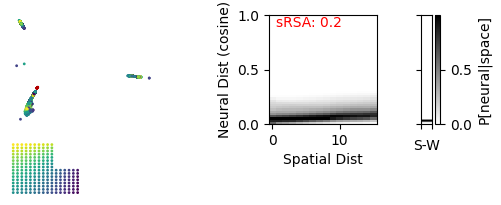

Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/representationalGeometryAnalysis.py:382: RuntimeWarning: invalid value encountered in divide
  hist2 = hist2/np.sum(hist2,axis=0)
/gpfs/radev/project/saxen

Running SLEEP
Fitting Isomap


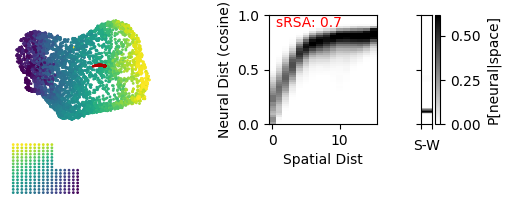

In [ ]:
from prnn.analysis.representationalGeometryAnalysis import representationalGeometryAnalysis

sleepnoise = 0.03
isomap_neighbors = 15
dv_RGA = representationalGeometryAnalysis(divnorm_net, noisestd=sleepnoise,
                                       withIsomap=True, n_neighbors = isomap_neighbors)
dv_.WakeSleepFigure(netname='DivNorm')
norm_RGA = representationalGeometryAnalysis(norm_net, noisestd=sleepnoise,
                                       withIsomap=True, n_neighbors = isomap_neighbors)
norm_RGA.WakeSleepFigure(netname='Norm')

/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


Calculating EV_s
Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.grid to get variables from other wrappers is deprecated and will be removed in v1.0,

/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/TuningCurveAnalysis.py:372: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


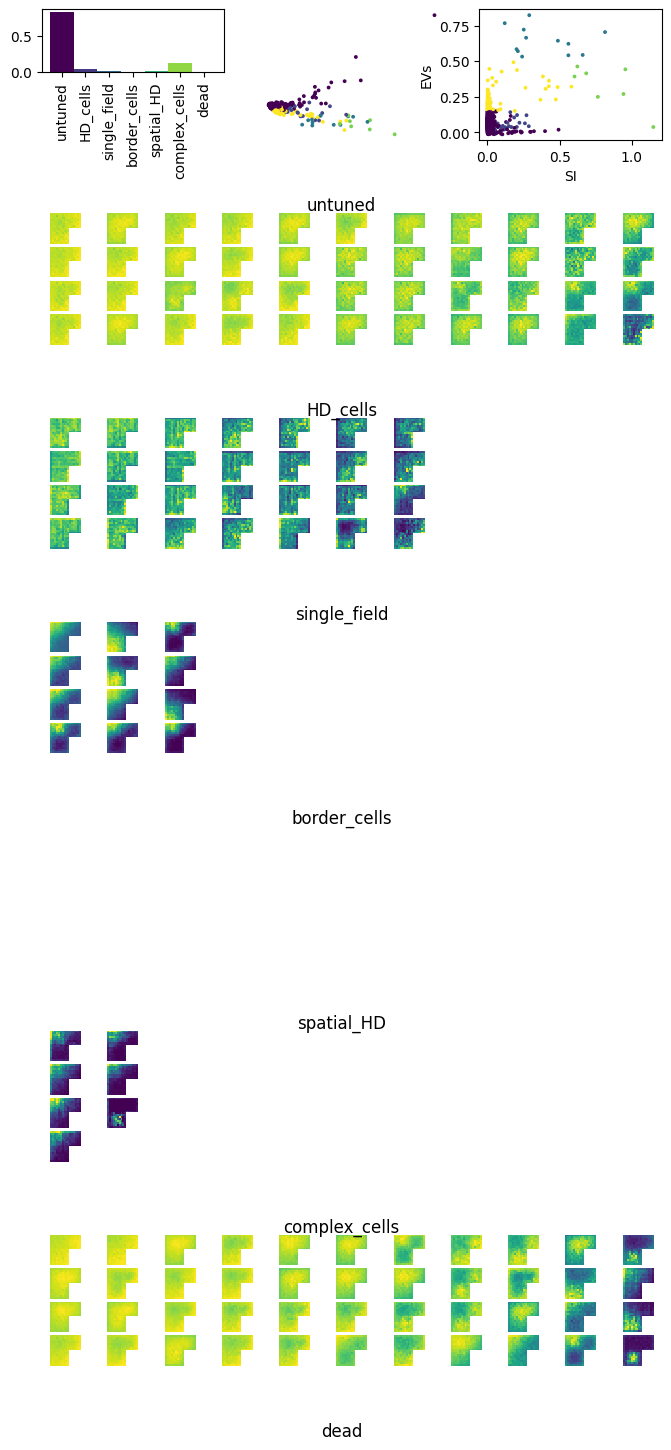

/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:378: RuntimeWarning: invalid value encountered in divide
  fxfr = fx / fr
/gpfs/radev/home/mc386

Calculating EV_s
Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.grid to get variables from other wrappers is deprecated and will be removed in v1.0,

/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/TuningCurveAnalysis.py:488: RuntimeWarning: invalid value encountered in divide
  autocorr = autocorr / np.max(autocorr, axis=None)


dead cell
dead cell
dead cell
dead cell


/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/TuningCurveAnalysis.py:541: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(coords.T)
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/TuningCurveAnalysis.py:372: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


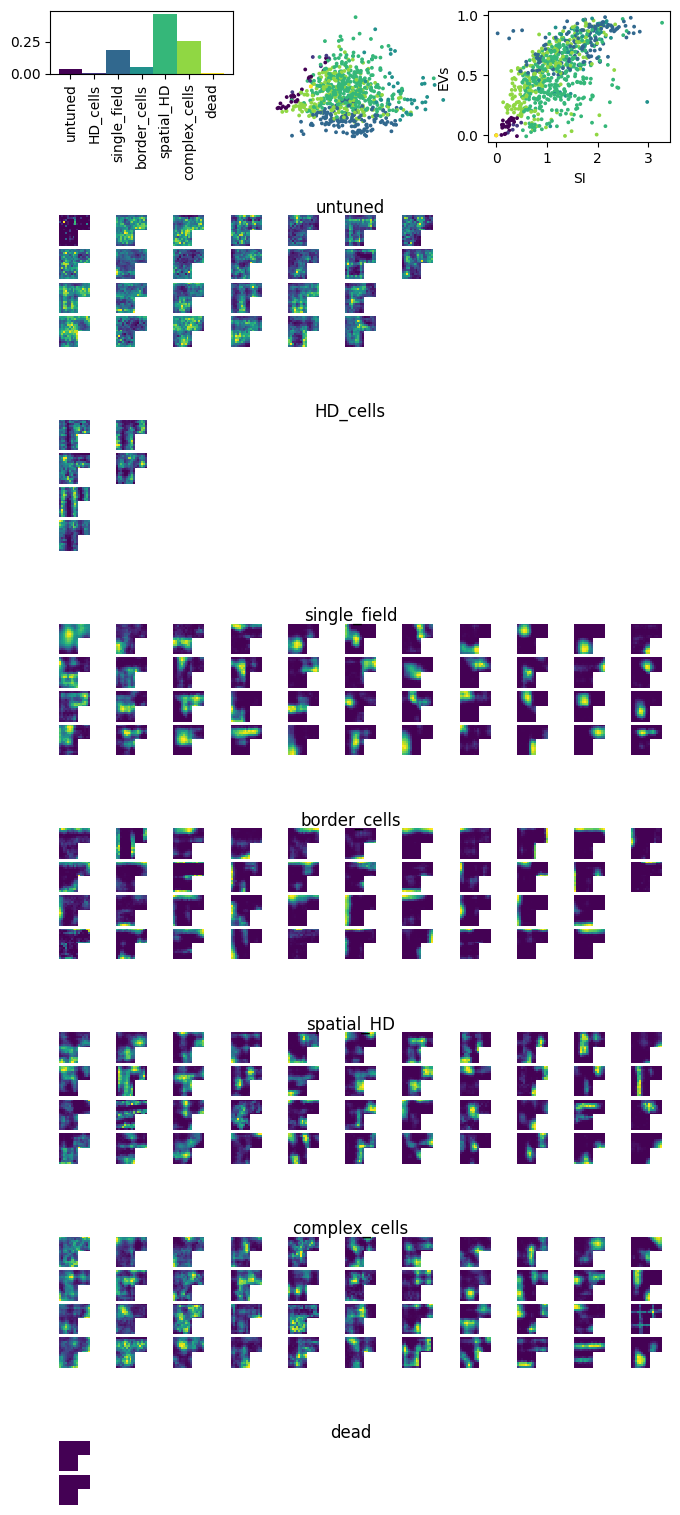

In [11]:
dv_tuning_curve_analysis = TuningCurveAnalysis(divnorm_net)
dv_tuning_curve_analysis.cellClassificationFigure()
norm_tuning_curve_analysis = TuningCurveAnalysis(norm_net)
norm_tuning_curve_analysis.cellClassificationFigure()

In [6]:
eg_nets = []
for i in range(5): 
    for j in range(5):
        net = pNet.PredictiveNet.loadNet(f'eg_lr_wd_sweep/Masked-{i}_{j}-s8')
        eg_nets.append(net)
        print(net.trainArgs.eg_lr)
        print(net.trainArgs.eg_weight_decay)

Net Loaded from pathname
0.00055
1e-07
Net Loaded from pathname
0.00055
3e-07
Net Loaded from pathname
0.00055
5e-07
Net Loaded from pathname
0.00055
7e-07
Net Loaded from pathname
0.00055
9e-07
Net Loaded from pathname
0.0008
1e-07
Net Loaded from pathname
0.0008
3e-07
Net Loaded from pathname
0.0008
5e-07
Net Loaded from pathname
0.0008
7e-07
Net Loaded from pathname
0.0008
9e-07
Net Loaded from pathname
0.001
1e-07
Net Loaded from pathname
0.001
3e-07
Net Loaded from pathname
0.001
5e-07
Net Loaded from pathname
0.001
7e-07
Net Loaded from pathname
0.001
9e-07
Net Loaded from pathname
0.0018
1e-07
Net Loaded from pathname
0.0018
3e-07
Net Loaded from pathname
0.0018
5e-07
Net Loaded from pathname
0.0018
7e-07
Net Loaded from pathname
0.0018
9e-07
Net Loaded from pathname
0.003
1e-07
Net Loaded from pathname
0.003
3e-07
Net Loaded from pathname
0.003
5e-07
Net Loaded from pathname
0.003
7e-07
Net Loaded from pathname
0.003
9e-07


In [19]:
divnorm_net.trainArgs.eg_lr

0.002

0.001 5e-07
Training Decoder on cuda...
loss: 5.799809 [    0\ 5000]
loss: 2.121946 [  500\ 5000]
loss: 1.614687 [ 1000\ 5000]
loss: 1.336320 [ 1500\ 5000]
loss: 1.167464 [ 2000\ 5000]
loss: 1.029225 [ 2500\ 5000]
loss: 0.926333 [ 3000\ 5000]
loss: 0.862394 [ 3500\ 5000]
loss: 0.787847 [ 4000\ 5000]
loss: 0.748872 [ 4500\ 5000]
loss: 0.697449 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


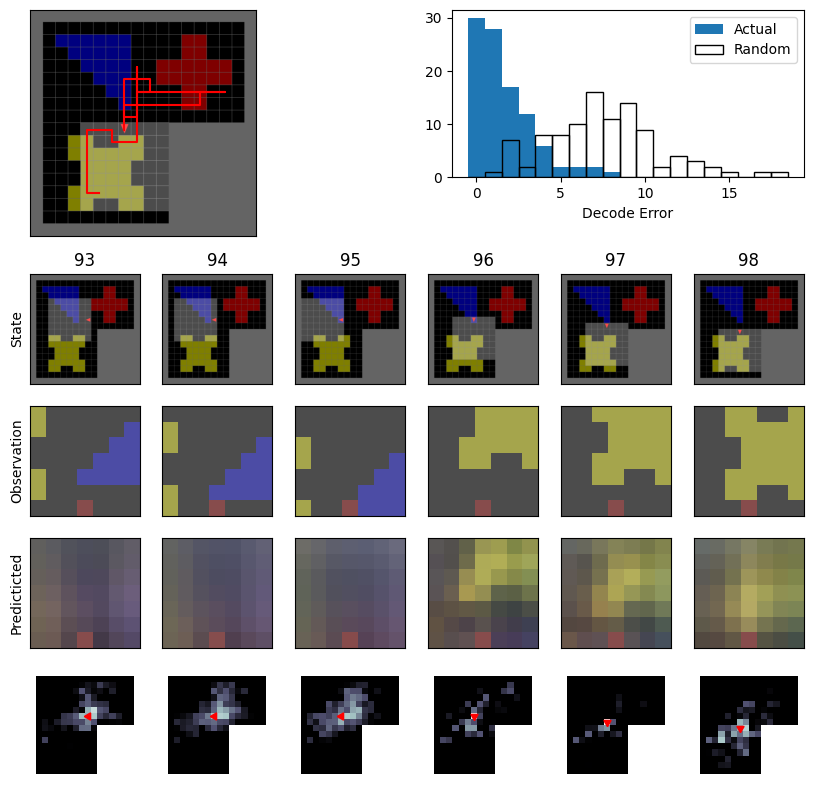

Calculating EV_s
Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.grid to get variables from other wrappers is deprecated and will be removed in v1.0,

/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/TuningCurveAnalysis.py:372: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


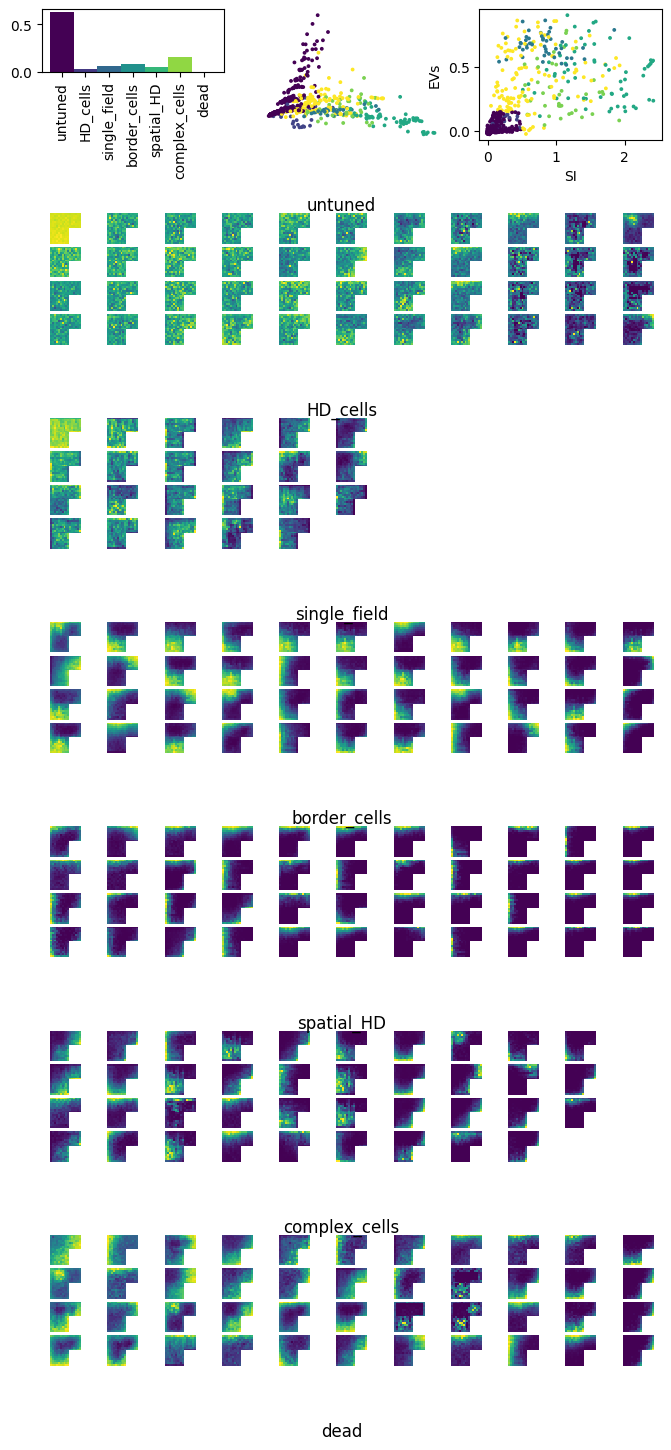

Running WAKE


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/project/saxena/mc3863/pRNN/prnn/analysis/representationalGeometryAnalysis.py:382: RuntimeWarning: invalid value encountered in divide
  hist2 = hist2/np.sum(hist2,axis=0)
/gpfs/radev/project/saxen

Running SLEEP
Fitting Isomap


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


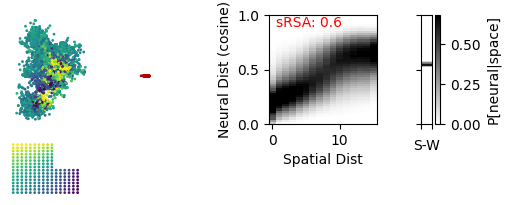

In [12]:
from prnn.analysis.representationalGeometryAnalysis import representationalGeometryAnalysis

sleepnoise = 0.03
isomap_neighbors = 15
net = eg_nets[12]
print(net.trainArgs.eg_lr, net.trainArgs.eg_weight_decay)
place_fields, SI, decoder = net.calculateSpatialRepresentation(env,agent,
                                              trainDecoder=True)
net.calculateDecodingPerformance(env,agent,decoder,
                                              savename=None, savefolder=None,
                                            trajectoryWindow=100,
                                            timesteps=100)
tuning_curve_analysis = TuningCurveAnalysis(net)
tuning_curve_analysis.cellClassificationFigure()
RGA = representationalGeometryAnalysis(net, noisestd=sleepnoise,
                                       withIsomap=True, n_neighbors = isomap_neighbors)
RGA.WakeSleepFigure(netname='Div')

<class 'prnn.utils.thetaRNN.RNNCell'> 10
(3, 7)
{}
Learning Rate:  0.00055
Weight Decay:  1e-07
Training Decoder on cuda...
loss: 5.885397 [    0\ 5000]
loss: 3.400126 [  500\ 5000]
loss: 2.968287 [ 1000\ 5000]
loss: 2.662066 [ 1500\ 5000]
loss: 2.486791 [ 2000\ 5000]
loss: 2.317538 [ 2500\ 5000]
loss: 2.230416 [ 3000\ 5000]
loss: 2.118337 [ 3500\ 5000]
loss: 2.056182 [ 4000\ 5000]
loss: 1.987532 [ 4500\ 5000]
loss: 1.930074 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


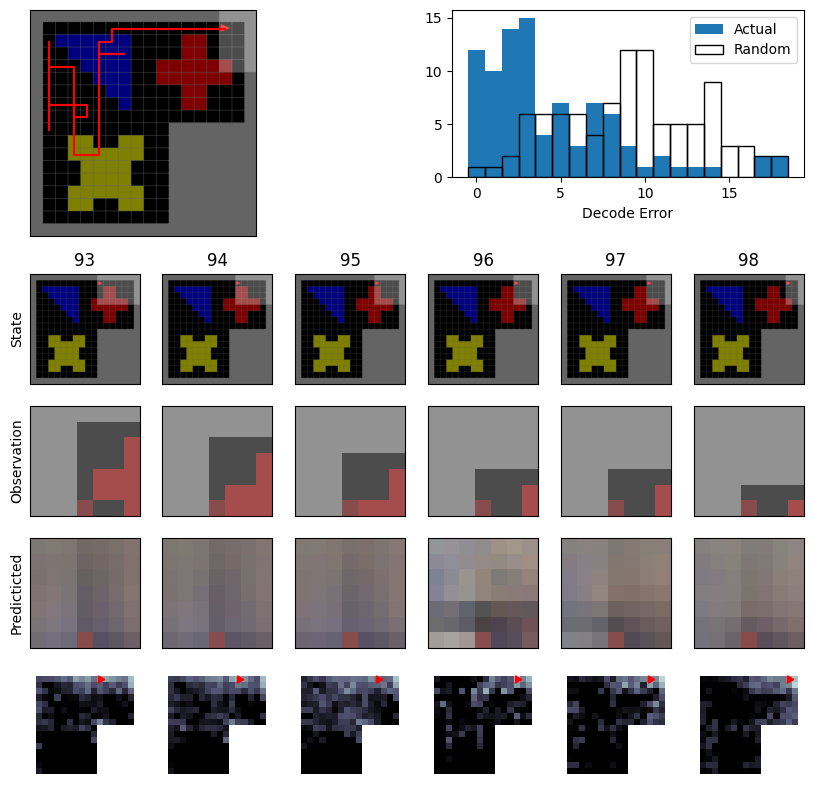

Learning Rate:  0.00055
Weight Decay:  3e-07


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


Training Decoder on cuda...
loss: 5.802377 [    0\ 5000]
loss: 2.414311 [  500\ 5000]
loss: 1.920327 [ 1000\ 5000]
loss: 1.648298 [ 1500\ 5000]
loss: 1.452933 [ 2000\ 5000]
loss: 1.314237 [ 2500\ 5000]
loss: 1.202977 [ 3000\ 5000]
loss: 1.136775 [ 3500\ 5000]
loss: 1.064498 [ 4000\ 5000]
loss: 0.999216 [ 4500\ 5000]
loss: 0.947007 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


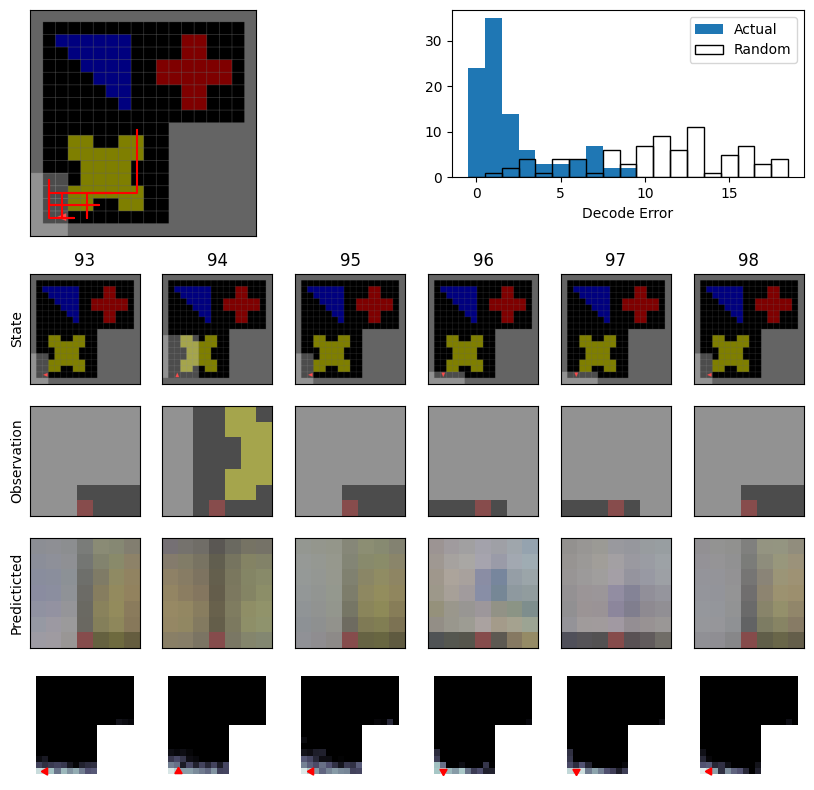

Learning Rate:  0.00055
Weight Decay:  5e-07
Training Decoder on cuda...
loss: 5.804257 [    0\ 5000]
loss: 2.590229 [  500\ 5000]
loss: 2.050506 [ 1000\ 5000]
loss: 1.752298 [ 1500\ 5000]
loss: 1.538271 [ 2000\ 5000]
loss: 1.380151 [ 2500\ 5000]
loss: 1.267364 [ 3000\ 5000]
loss: 1.189708 [ 3500\ 5000]
loss: 1.111749 [ 4000\ 5000]
loss: 1.049969 [ 4500\ 5000]
loss: 0.997162 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


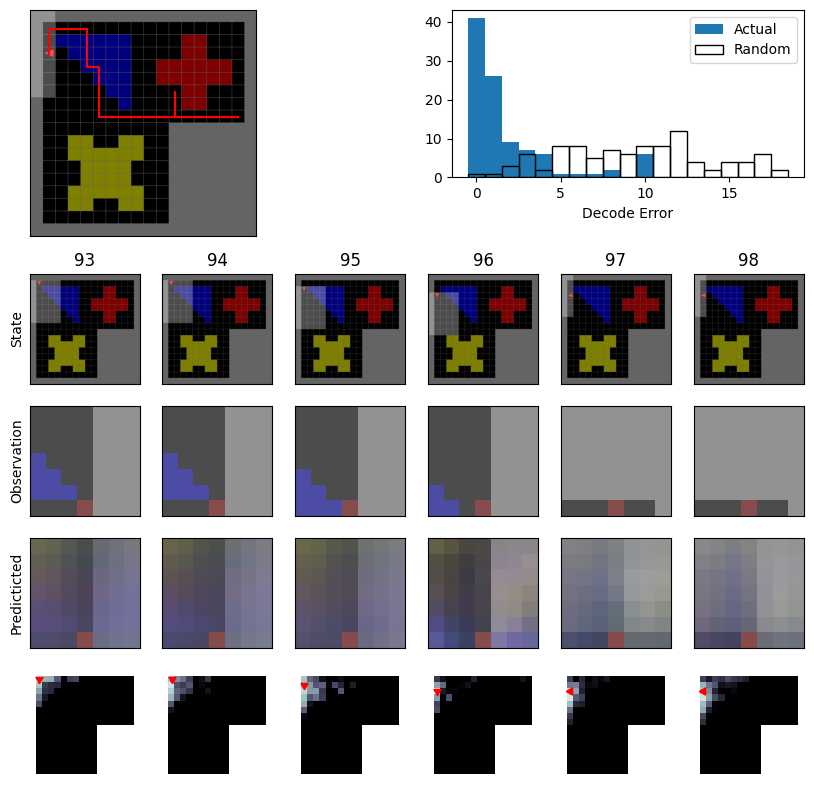

Learning Rate:  0.00055
Weight Decay:  7e-07
Training Decoder on cuda...
loss: 5.787053 [    0\ 5000]
loss: 2.816534 [  500\ 5000]
loss: 2.259995 [ 1000\ 5000]
loss: 1.946685 [ 1500\ 5000]
loss: 1.739993 [ 2000\ 5000]
loss: 1.575984 [ 2500\ 5000]
loss: 1.450314 [ 3000\ 5000]
loss: 1.353358 [ 3500\ 5000]
loss: 1.269040 [ 4000\ 5000]
loss: 1.209063 [ 4500\ 5000]
loss: 1.151908 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


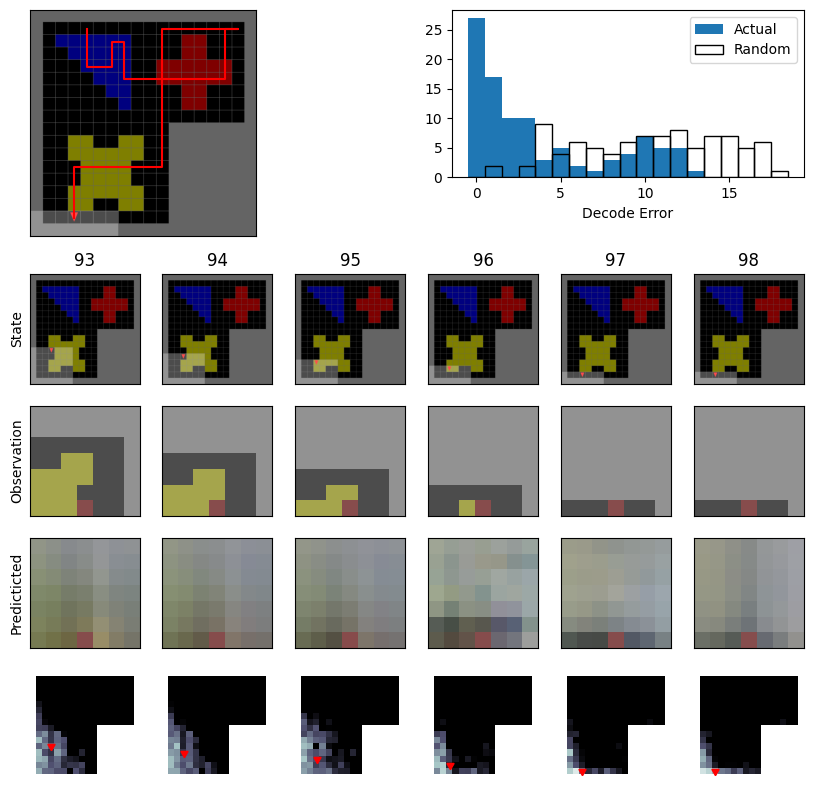

Learning Rate:  0.00055
Weight Decay:  9e-07
Training Decoder on cuda...
loss: 5.800254 [    0\ 5000]
loss: 2.982007 [  500\ 5000]
loss: 2.414730 [ 1000\ 5000]
loss: 2.066875 [ 1500\ 5000]
loss: 1.851177 [ 2000\ 5000]
loss: 1.697138 [ 2500\ 5000]
loss: 1.571255 [ 3000\ 5000]
loss: 1.477861 [ 3500\ 5000]
loss: 1.398687 [ 4000\ 5000]
loss: 1.329277 [ 4500\ 5000]
loss: 1.274504 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


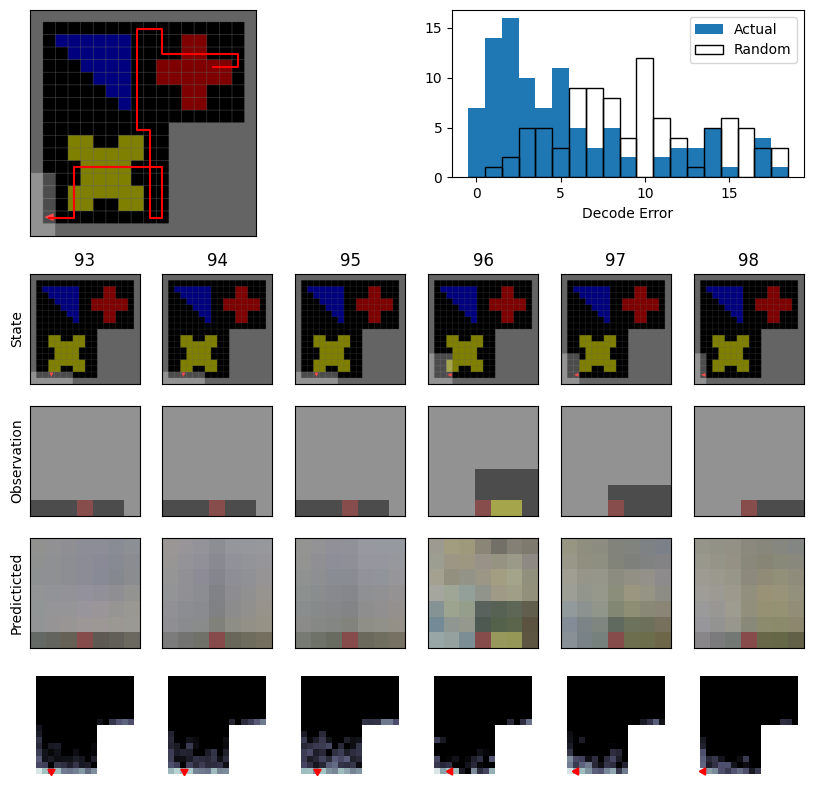

Learning Rate:  0.0008
Weight Decay:  1e-07
Training Decoder on cuda...
loss: 5.869391 [    0\ 5000]
loss: 3.056680 [  500\ 5000]
loss: 2.574120 [ 1000\ 5000]
loss: 2.318172 [ 1500\ 5000]
loss: 2.129234 [ 2000\ 5000]
loss: 1.978606 [ 2500\ 5000]
loss: 1.855243 [ 3000\ 5000]
loss: 1.787117 [ 3500\ 5000]
loss: 1.713575 [ 4000\ 5000]
loss: 1.649370 [ 4500\ 5000]
loss: 1.605504 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


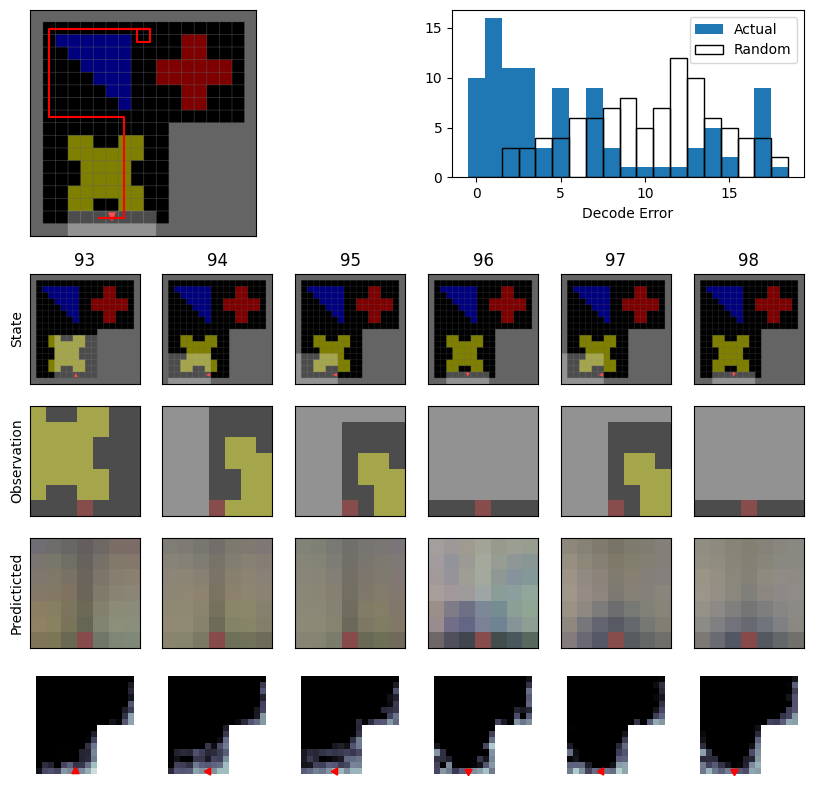

Learning Rate:  0.0008
Weight Decay:  3e-07
Training Decoder on cuda...
loss: 5.797173 [    0\ 5000]
loss: 1.979136 [  500\ 5000]
loss: 1.516626 [ 1000\ 5000]
loss: 1.269697 [ 1500\ 5000]
loss: 1.095868 [ 2000\ 5000]
loss: 0.978117 [ 2500\ 5000]
loss: 0.885318 [ 3000\ 5000]
loss: 0.819237 [ 3500\ 5000]
loss: 0.751698 [ 4000\ 5000]
loss: 0.703821 [ 4500\ 5000]
loss: 0.650709 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


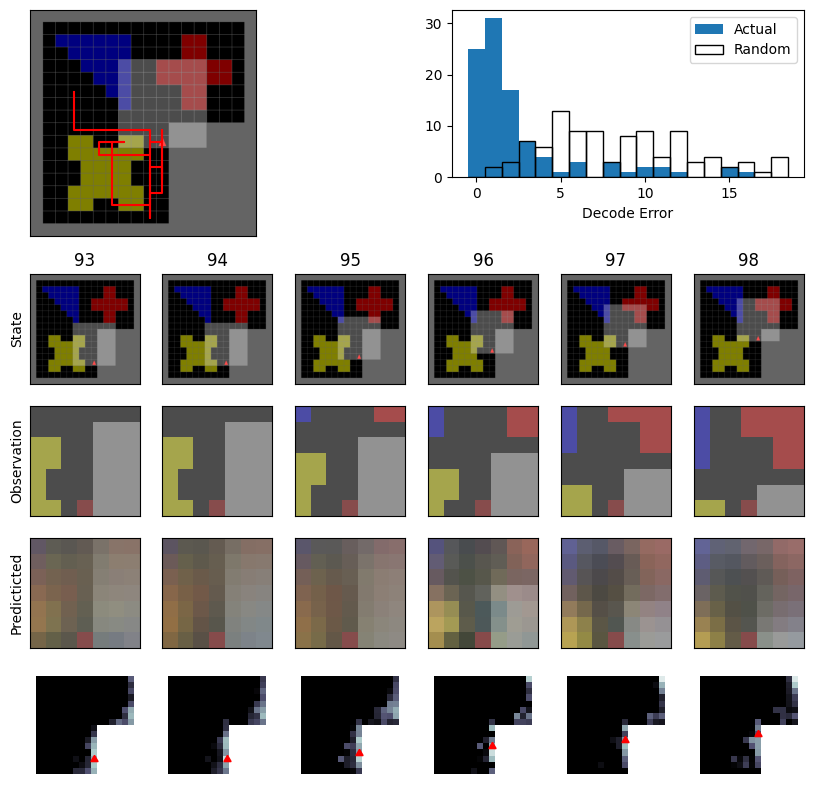

Learning Rate:  0.0008
Weight Decay:  5e-07
Training Decoder on cuda...
loss: 5.793297 [    0\ 5000]
loss: 2.292483 [  500\ 5000]
loss: 1.782317 [ 1000\ 5000]
loss: 1.506196 [ 1500\ 5000]
loss: 1.316257 [ 2000\ 5000]
loss: 1.177403 [ 2500\ 5000]
loss: 1.079407 [ 3000\ 5000]
loss: 1.000538 [ 3500\ 5000]
loss: 0.928211 [ 4000\ 5000]
loss: 0.859287 [ 4500\ 5000]
loss: 0.815857 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


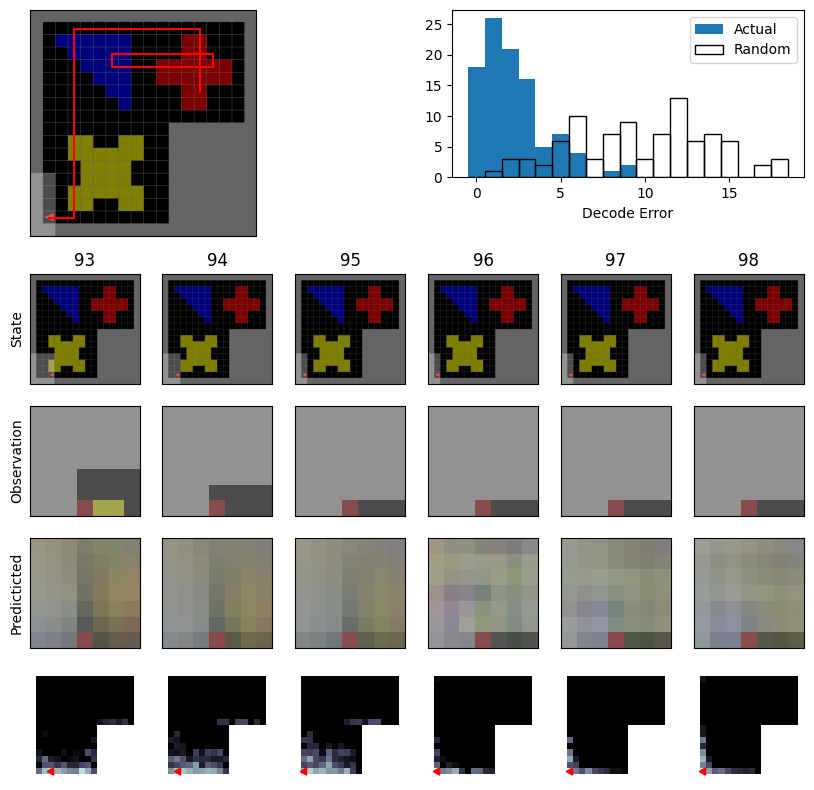

Learning Rate:  0.0008
Weight Decay:  7e-07
Training Decoder on cuda...
loss: 5.767452 [    0\ 5000]
loss: 2.447129 [  500\ 5000]
loss: 1.922995 [ 1000\ 5000]
loss: 1.651486 [ 1500\ 5000]
loss: 1.442567 [ 2000\ 5000]
loss: 1.288312 [ 2500\ 5000]
loss: 1.181221 [ 3000\ 5000]
loss: 1.085120 [ 3500\ 5000]
loss: 1.021978 [ 4000\ 5000]
loss: 0.953411 [ 4500\ 5000]
loss: 0.912294 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


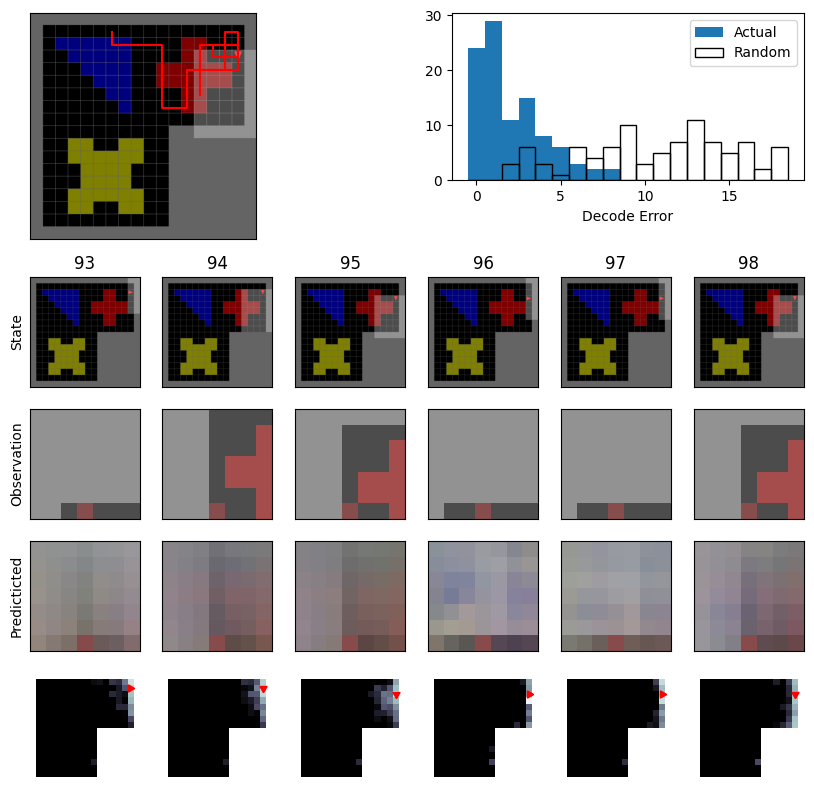

Learning Rate:  0.0008
Weight Decay:  9e-07
Training Decoder on cuda...
loss: 5.786366 [    0\ 5000]
loss: 2.678061 [  500\ 5000]
loss: 2.104944 [ 1000\ 5000]
loss: 1.809346 [ 1500\ 5000]
loss: 1.619063 [ 2000\ 5000]
loss: 1.462547 [ 2500\ 5000]
loss: 1.330165 [ 3000\ 5000]
loss: 1.247733 [ 3500\ 5000]
loss: 1.178386 [ 4000\ 5000]
loss: 1.111982 [ 4500\ 5000]
loss: 1.068782 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


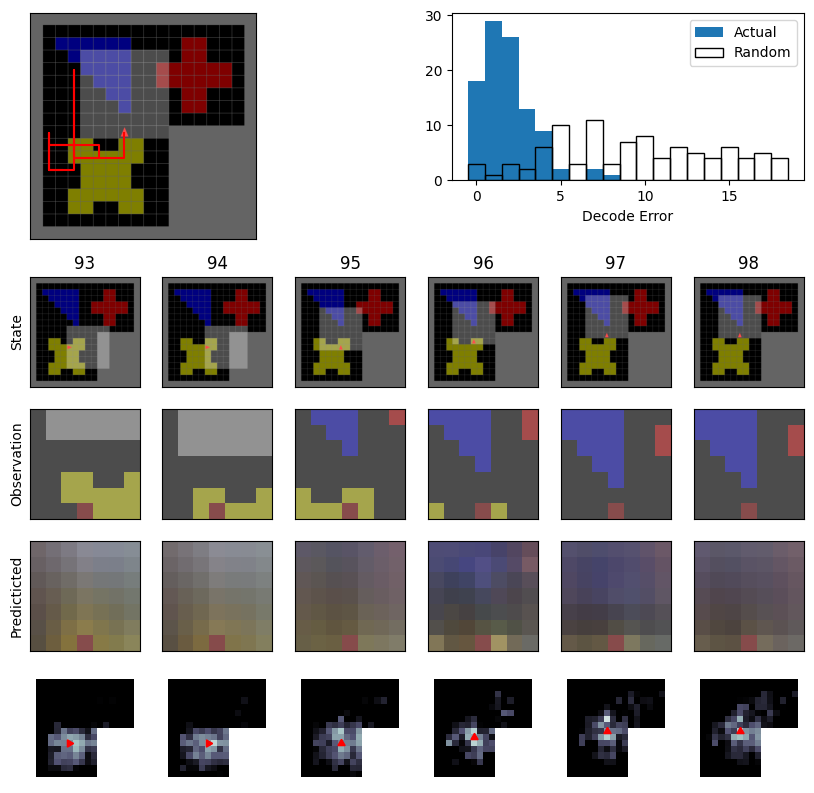

Learning Rate:  0.001
Weight Decay:  1e-07
Training Decoder on cuda...
loss: 5.882359 [    0\ 5000]
loss: 2.921253 [  500\ 5000]
loss: 2.466721 [ 1000\ 5000]
loss: 2.187954 [ 1500\ 5000]
loss: 1.993417 [ 2000\ 5000]
loss: 1.869104 [ 2500\ 5000]
loss: 1.754139 [ 3000\ 5000]
loss: 1.670744 [ 3500\ 5000]
loss: 1.602242 [ 4000\ 5000]
loss: 1.539140 [ 4500\ 5000]
loss: 1.488849 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


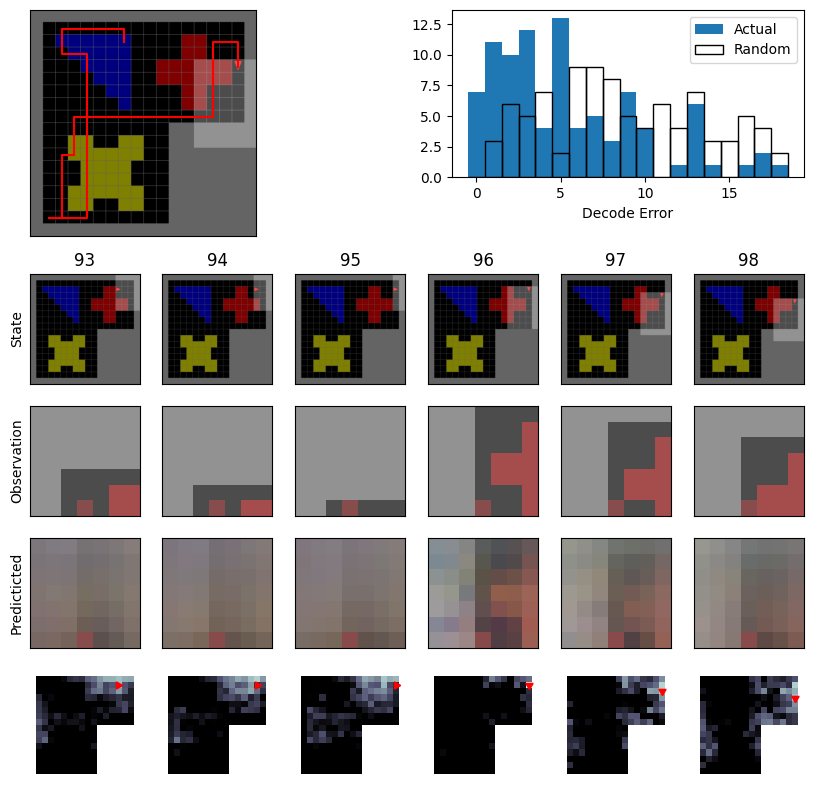

Learning Rate:  0.001
Weight Decay:  3e-07
Training Decoder on cuda...
loss: 5.802499 [    0\ 5000]
loss: 1.954497 [  500\ 5000]
loss: 1.502831 [ 1000\ 5000]
loss: 1.253746 [ 1500\ 5000]
loss: 1.083981 [ 2000\ 5000]
loss: 0.965290 [ 2500\ 5000]
loss: 0.864286 [ 3000\ 5000]
loss: 0.804349 [ 3500\ 5000]
loss: 0.726498 [ 4000\ 5000]
loss: 0.682289 [ 4500\ 5000]
loss: 0.640404 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


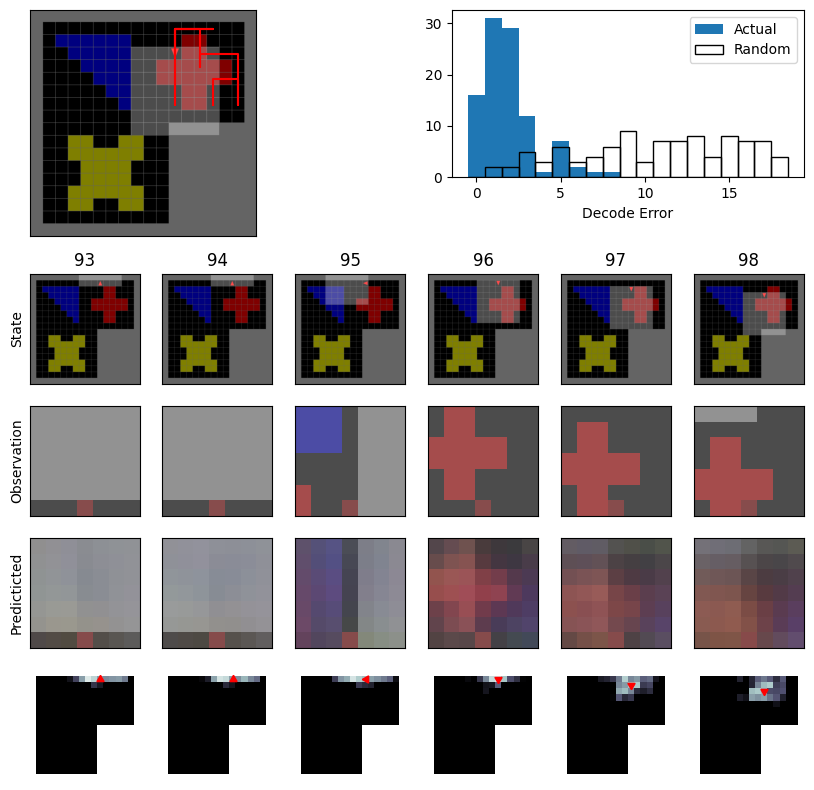

Learning Rate:  0.001
Weight Decay:  5e-07
Training Decoder on cuda...
loss: 5.785756 [    0\ 5000]
loss: 2.157168 [  500\ 5000]
loss: 1.653197 [ 1000\ 5000]
loss: 1.379075 [ 1500\ 5000]
loss: 1.198861 [ 2000\ 5000]
loss: 1.067432 [ 2500\ 5000]
loss: 0.955713 [ 3000\ 5000]
loss: 0.880024 [ 3500\ 5000]
loss: 0.824996 [ 4000\ 5000]
loss: 0.761223 [ 4500\ 5000]
loss: 0.715683 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


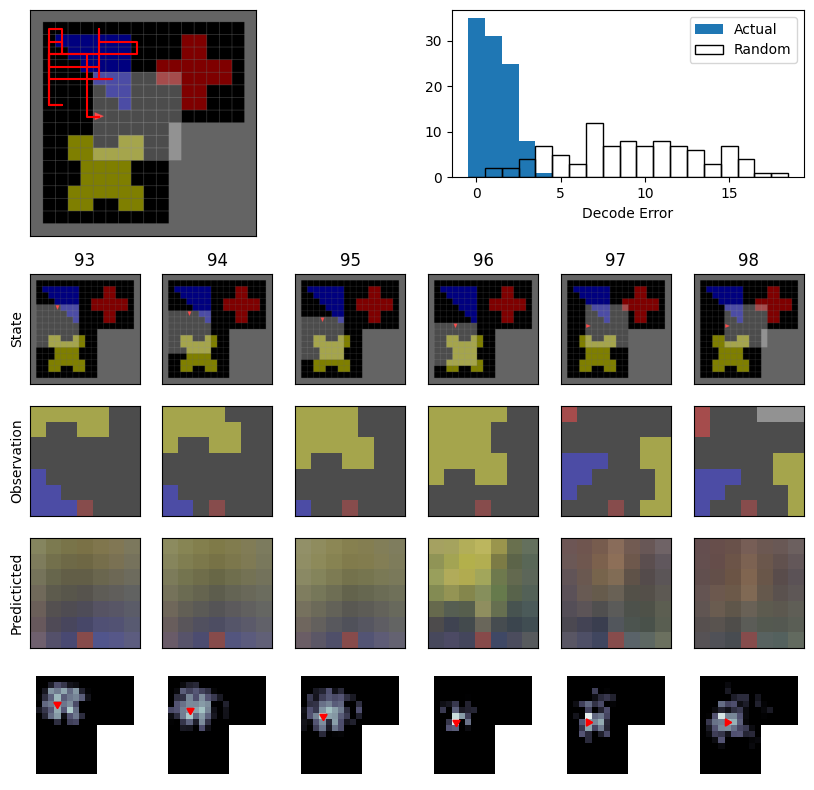

Learning Rate:  0.001
Weight Decay:  7e-07
Training Decoder on cuda...
loss: 5.758836 [    0\ 5000]
loss: 2.401775 [  500\ 5000]
loss: 1.865363 [ 1000\ 5000]
loss: 1.592310 [ 1500\ 5000]
loss: 1.389488 [ 2000\ 5000]
loss: 1.255403 [ 2500\ 5000]
loss: 1.140124 [ 3000\ 5000]
loss: 1.058576 [ 3500\ 5000]
loss: 0.970332 [ 4000\ 5000]
loss: 0.920714 [ 4500\ 5000]
loss: 0.870024 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


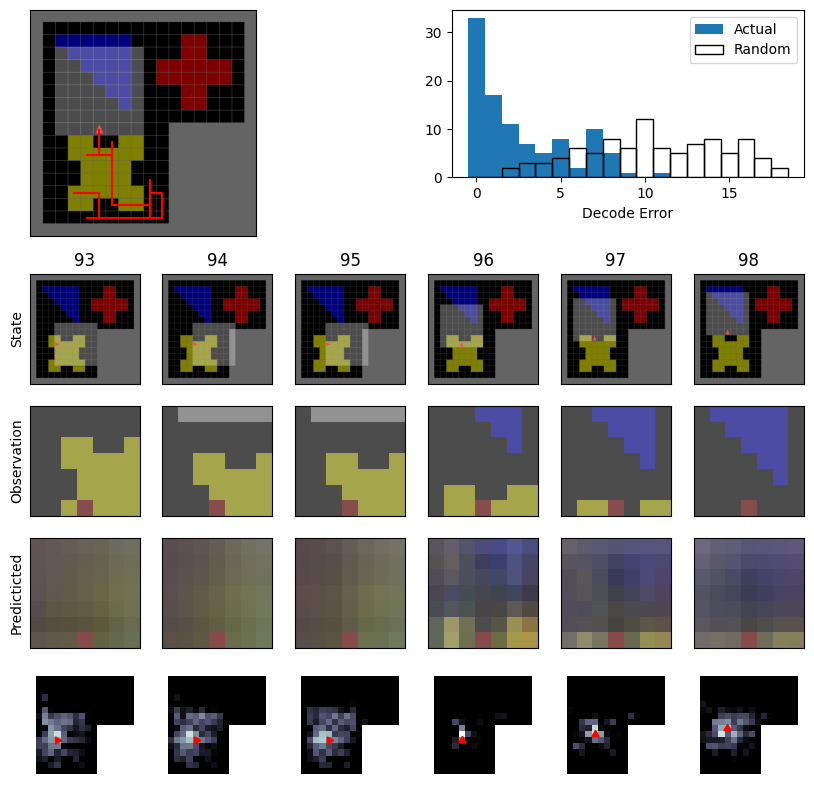

Learning Rate:  0.001
Weight Decay:  9e-07
Training Decoder on cuda...
loss: 5.770343 [    0\ 5000]
loss: 2.615341 [  500\ 5000]
loss: 2.047116 [ 1000\ 5000]
loss: 1.734859 [ 1500\ 5000]
loss: 1.511627 [ 2000\ 5000]
loss: 1.382069 [ 2500\ 5000]
loss: 1.257984 [ 3000\ 5000]
loss: 1.174604 [ 3500\ 5000]
loss: 1.085685 [ 4000\ 5000]
loss: 1.029063 [ 4500\ 5000]
loss: 0.967270 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


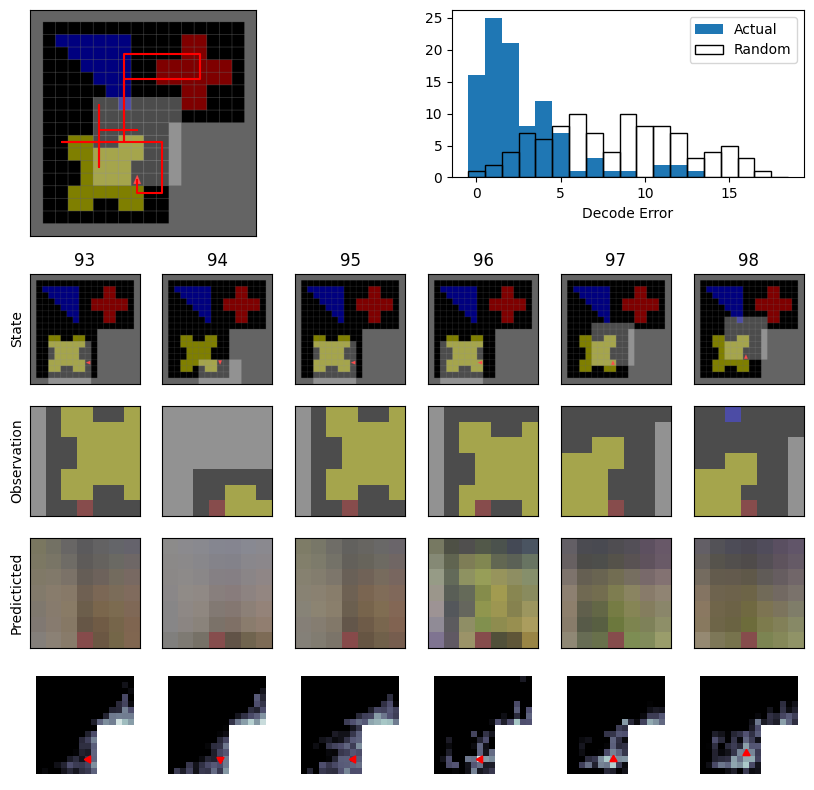

Learning Rate:  0.0018
Weight Decay:  1e-07
Training Decoder on cuda...
loss: 5.804673 [    0\ 5000]
loss: 2.383454 [  500\ 5000]
loss: 1.912059 [ 1000\ 5000]
loss: 1.656861 [ 1500\ 5000]
loss: 1.485641 [ 2000\ 5000]
loss: 1.355529 [ 2500\ 5000]
loss: 1.269622 [ 3000\ 5000]
loss: 1.190937 [ 3500\ 5000]
loss: 1.117869 [ 4000\ 5000]
loss: 1.063933 [ 4500\ 5000]
loss: 1.025229 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


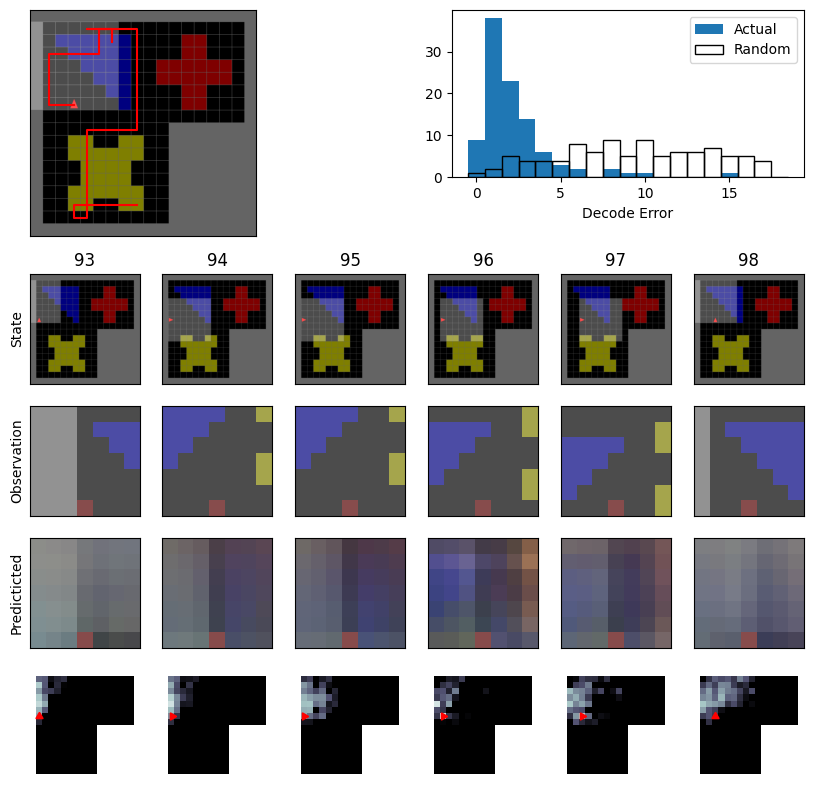

Learning Rate:  0.0018
Weight Decay:  3e-07
Training Decoder on cuda...
loss: 5.807969 [    0\ 5000]
loss: 1.794086 [  500\ 5000]
loss: 1.334608 [ 1000\ 5000]
loss: 1.114948 [ 1500\ 5000]
loss: 0.958189 [ 2000\ 5000]
loss: 0.839229 [ 2500\ 5000]
loss: 0.755796 [ 3000\ 5000]
loss: 0.686389 [ 3500\ 5000]
loss: 0.640495 [ 4000\ 5000]
loss: 0.583900 [ 4500\ 5000]
loss: 0.542020 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


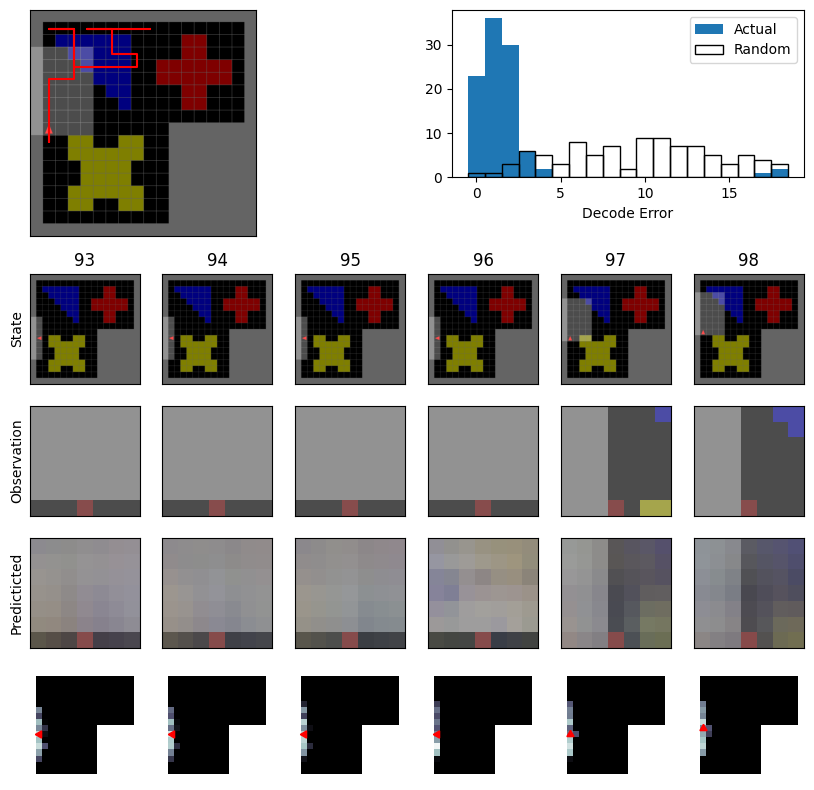

Learning Rate:  0.0018
Weight Decay:  5e-07
Training Decoder on cuda...
loss: 5.807040 [    0\ 5000]
loss: 2.027889 [  500\ 5000]
loss: 1.557617 [ 1000\ 5000]
loss: 1.304230 [ 1500\ 5000]
loss: 1.129211 [ 2000\ 5000]
loss: 1.009777 [ 2500\ 5000]
loss: 0.909756 [ 3000\ 5000]
loss: 0.829450 [ 3500\ 5000]
loss: 0.767464 [ 4000\ 5000]
loss: 0.718986 [ 4500\ 5000]
loss: 0.684012 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


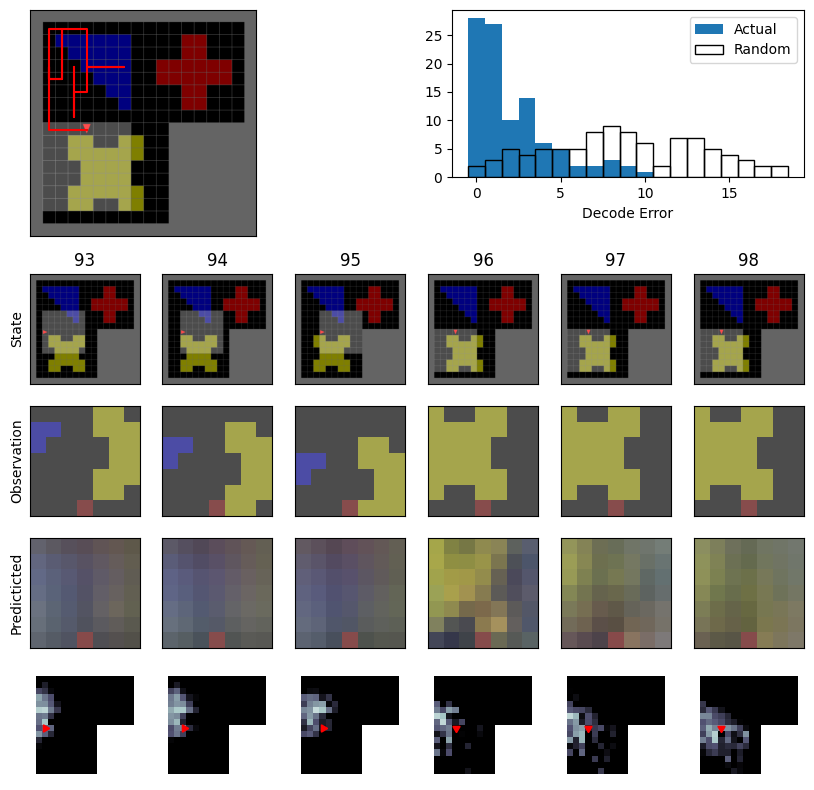

Learning Rate:  0.0018
Weight Decay:  7e-07
Training Decoder on cuda...
loss: 5.784854 [    0\ 5000]
loss: 2.223097 [  500\ 5000]
loss: 1.735599 [ 1000\ 5000]
loss: 1.446077 [ 1500\ 5000]
loss: 1.276849 [ 2000\ 5000]
loss: 1.134640 [ 2500\ 5000]
loss: 1.020273 [ 3000\ 5000]
loss: 0.945440 [ 3500\ 5000]
loss: 0.887978 [ 4000\ 5000]
loss: 0.826853 [ 4500\ 5000]
loss: 0.789956 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


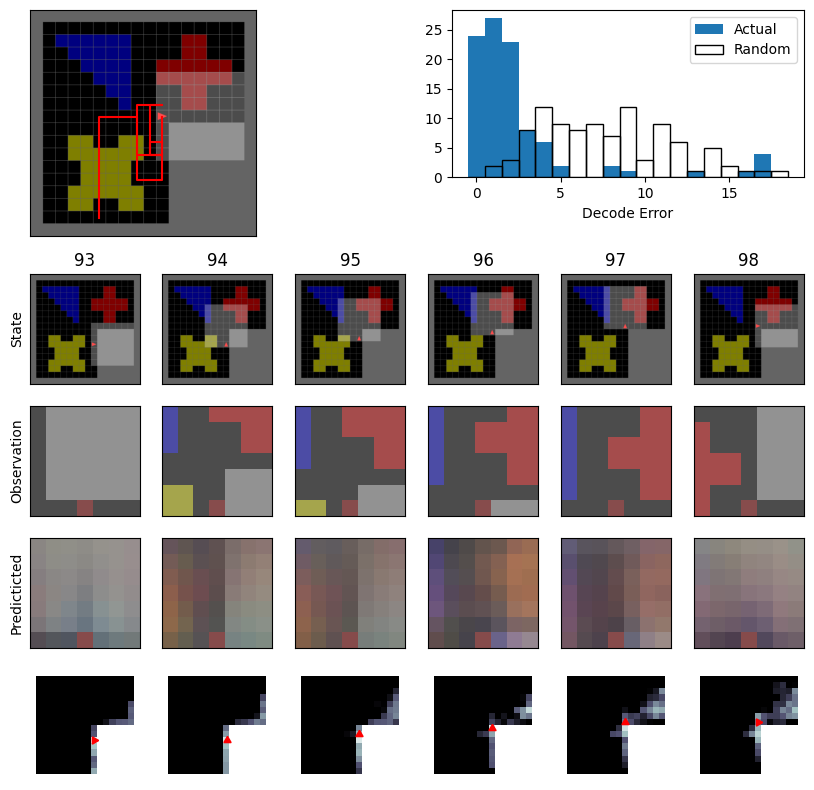

Learning Rate:  0.0018
Weight Decay:  9e-07
Training Decoder on cuda...
loss: 5.767114 [    0\ 5000]
loss: 2.356090 [  500\ 5000]
loss: 1.854513 [ 1000\ 5000]
loss: 1.580502 [ 1500\ 5000]
loss: 1.388891 [ 2000\ 5000]
loss: 1.255488 [ 2500\ 5000]
loss: 1.150157 [ 3000\ 5000]
loss: 1.061917 [ 3500\ 5000]
loss: 0.993267 [ 4000\ 5000]
loss: 0.926883 [ 4500\ 5000]
loss: 0.888198 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


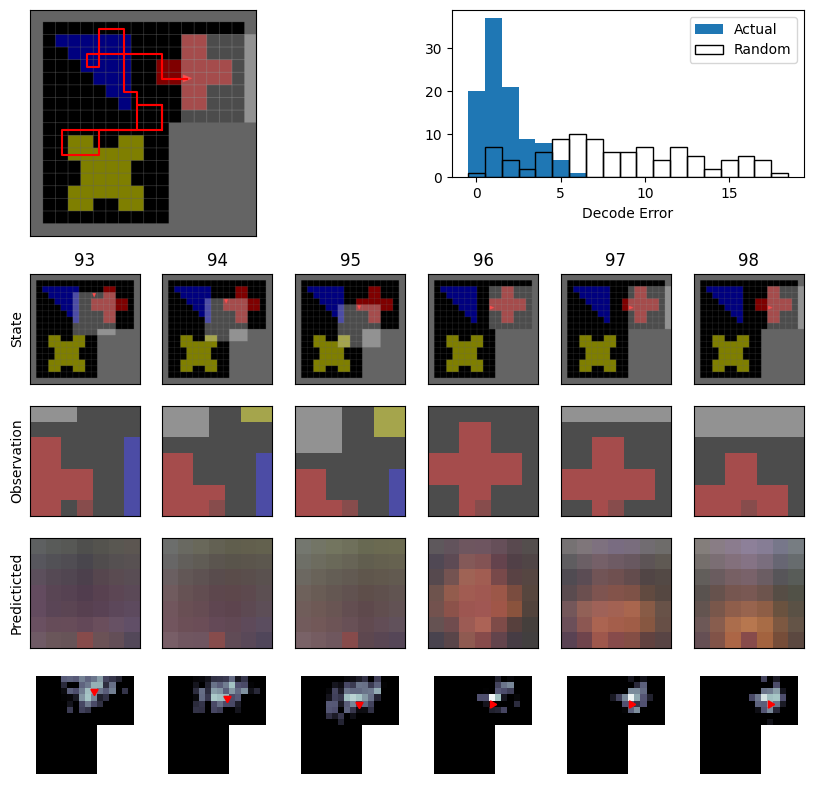

Learning Rate:  0.003
Weight Decay:  1e-07
Training Decoder on cuda...
loss: 5.831871 [    0\ 5000]
loss: 2.027020 [  500\ 5000]
loss: 1.572900 [ 1000\ 5000]
loss: 1.353965 [ 1500\ 5000]
loss: 1.207648 [ 2000\ 5000]
loss: 1.084700 [ 2500\ 5000]
loss: 1.007232 [ 3000\ 5000]
loss: 0.933843 [ 3500\ 5000]
loss: 0.874374 [ 4000\ 5000]
loss: 0.831162 [ 4500\ 5000]
loss: 0.786829 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


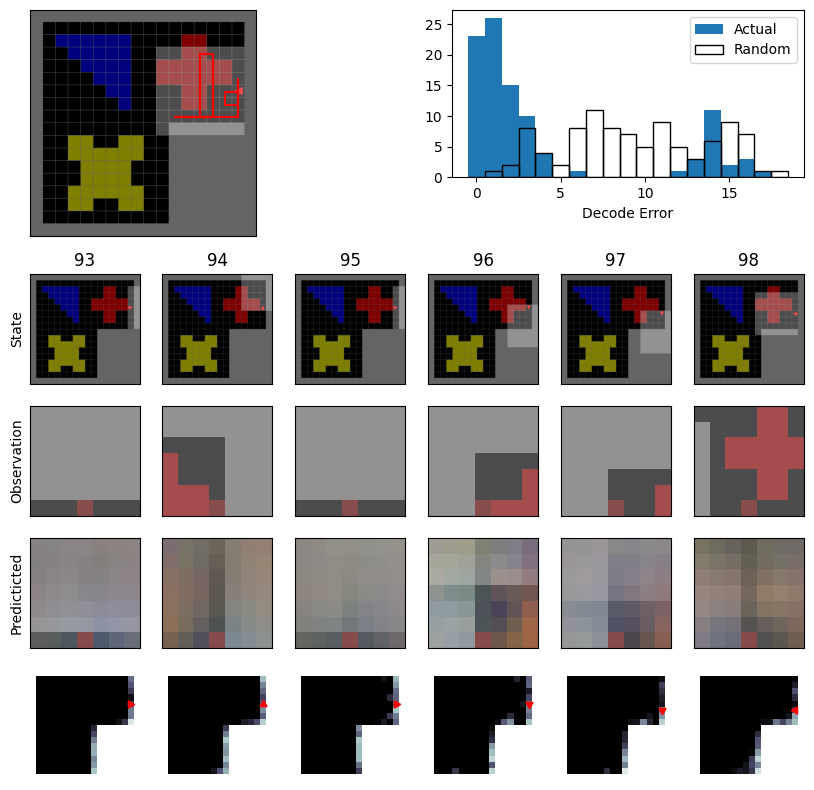

Learning Rate:  0.003
Weight Decay:  3e-07
Training Decoder on cuda...
loss: 5.810779 [    0\ 5000]
loss: 1.809756 [  500\ 5000]
loss: 1.356732 [ 1000\ 5000]
loss: 1.105917 [ 1500\ 5000]
loss: 0.948793 [ 2000\ 5000]
loss: 0.850505 [ 2500\ 5000]
loss: 0.758730 [ 3000\ 5000]
loss: 0.687495 [ 3500\ 5000]
loss: 0.641564 [ 4000\ 5000]
loss: 0.593482 [ 4500\ 5000]
loss: 0.552402 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


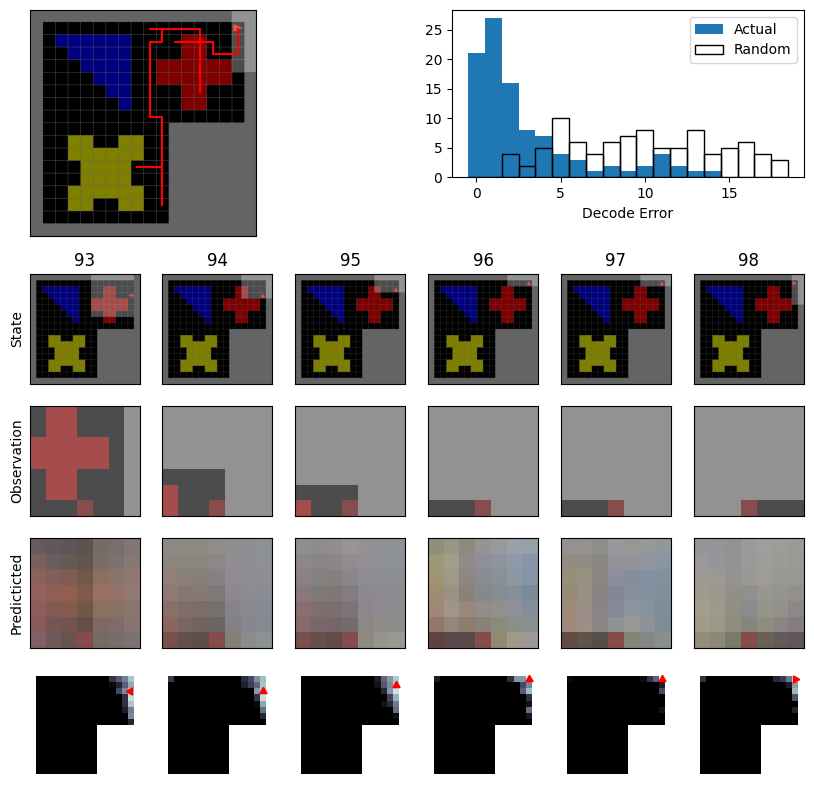

Learning Rate:  0.003
Weight Decay:  5e-07
Training Decoder on cuda...
loss: 5.781645 [    0\ 5000]
loss: 2.088379 [  500\ 5000]
loss: 1.620546 [ 1000\ 5000]
loss: 1.371869 [ 1500\ 5000]
loss: 1.190629 [ 2000\ 5000]
loss: 1.056525 [ 2500\ 5000]
loss: 0.964594 [ 3000\ 5000]
loss: 0.888344 [ 3500\ 5000]
loss: 0.821616 [ 4000\ 5000]
loss: 0.765871 [ 4500\ 5000]
loss: 0.722787 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


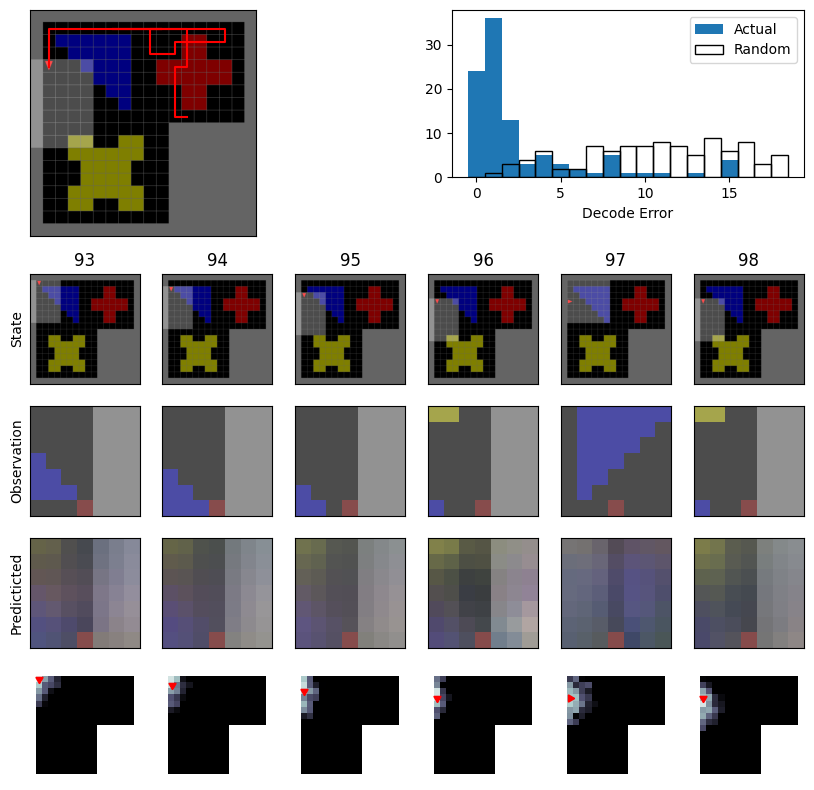

Learning Rate:  0.003
Weight Decay:  7e-07
Training Decoder on cuda...
loss: 5.796701 [    0\ 5000]
loss: 2.378571 [  500\ 5000]
loss: 1.897612 [ 1000\ 5000]
loss: 1.634310 [ 1500\ 5000]
loss: 1.443049 [ 2000\ 5000]
loss: 1.305157 [ 2500\ 5000]
loss: 1.180059 [ 3000\ 5000]
loss: 1.102985 [ 3500\ 5000]
loss: 1.031109 [ 4000\ 5000]
loss: 0.976158 [ 4500\ 5000]
loss: 0.930459 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


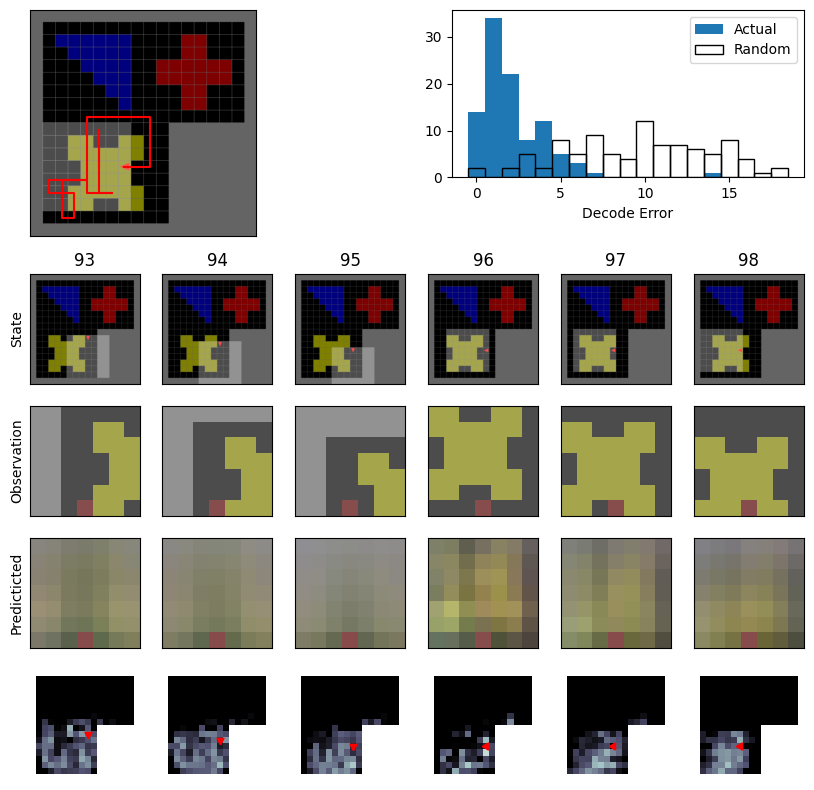

Learning Rate:  0.003
Weight Decay:  9e-07
Training Decoder on cuda...
loss: 5.750978 [    0\ 5000]
loss: 2.657048 [  500\ 5000]
loss: 2.171344 [ 1000\ 5000]
loss: 1.877874 [ 1500\ 5000]
loss: 1.669502 [ 2000\ 5000]
loss: 1.536262 [ 2500\ 5000]
loss: 1.403617 [ 3000\ 5000]
loss: 1.326964 [ 3500\ 5000]
loss: 1.247245 [ 4000\ 5000]
loss: 1.182189 [ 4500\ 5000]
loss: 1.136875 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


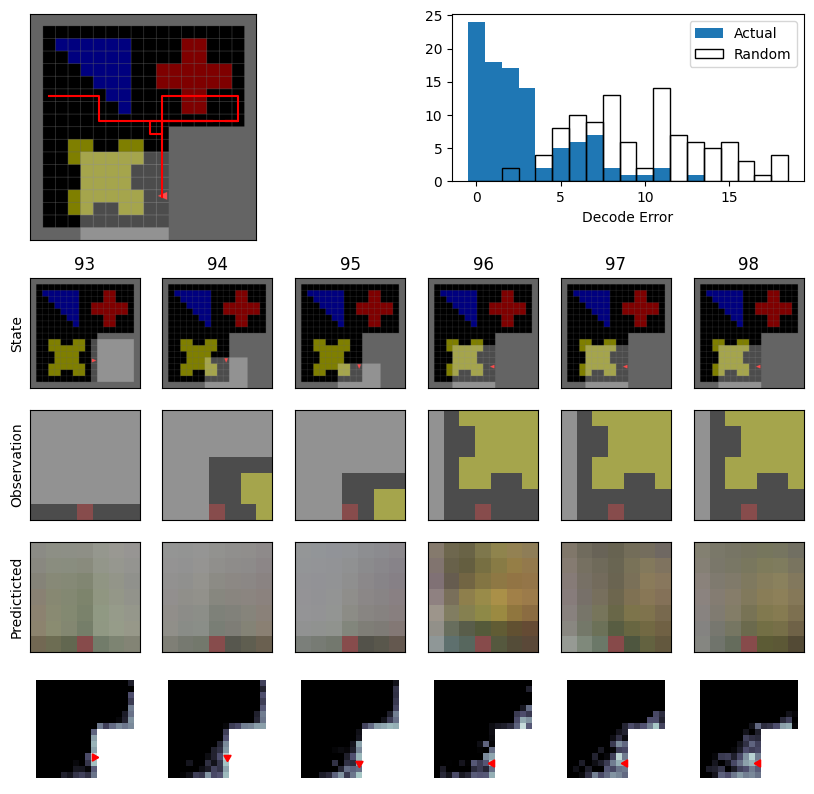

In [8]:
for net in eg_nets:
  print("Learning Rate: ", net.trainArgs.eg_lr)
  print("Weight Decay: ", net.trainArgs.eg_weight_decay)
  place_fields, SI, decoder = net.calculateSpatialRepresentation(env,agent,
                                              trainDecoder=True)
  net.calculateDecodingPerformance(env,agent,decoder,
                                              savename=None, savefolder=None,
                                            trajectoryWindow=100,
                                            timesteps=100)

In [ ]:
#winner is 1e-.06

Net Loaded from pathname
1e-06
Net Loaded from pathname
1e-05
Net Loaded from pathname
0.0001
Net Loaded from pathname
0.001
Net Loaded from pathname
0.01
Net Loaded from pathname
0.1
0.002


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


Training Decoder on cuda...
loss: 5.789896 [    0\ 5000]
loss: 2.657864 [  500\ 5000]
loss: 2.143009 [ 1000\ 5000]
loss: 1.865666 [ 1500\ 5000]
loss: 1.657509 [ 2000\ 5000]
loss: 1.510501 [ 2500\ 5000]
loss: 1.410544 [ 3000\ 5000]
loss: 1.320361 [ 3500\ 5000]
loss: 1.244370 [ 4000\ 5000]
loss: 1.182102 [ 4500\ 5000]
loss: 1.137855 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


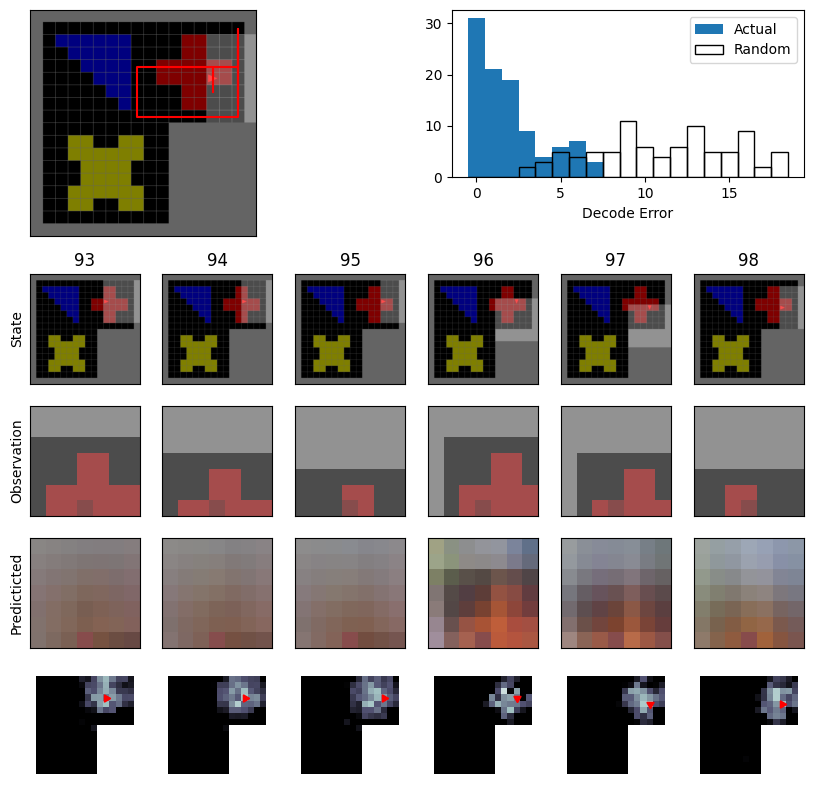

0.002
Training Decoder on cuda...
loss: 5.782813 [    0\ 5000]
loss: 4.775233 [  500\ 5000]
loss: 4.512017 [ 1000\ 5000]
loss: 4.281297 [ 1500\ 5000]
loss: 4.095347 [ 2000\ 5000]
loss: 3.934846 [ 2500\ 5000]
loss: 3.808625 [ 3000\ 5000]
loss: 3.711964 [ 3500\ 5000]
loss: 3.625794 [ 4000\ 5000]
loss: 3.556152 [ 4500\ 5000]
loss: 3.493787 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


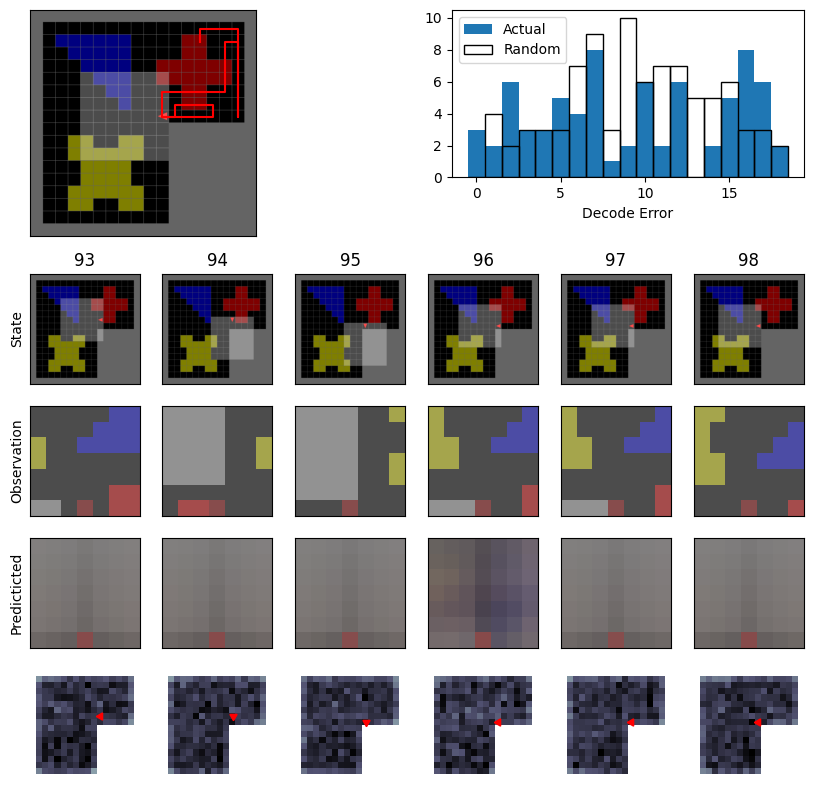

0.002
Training Decoder on cuda...
loss: 5.782624 [    0\ 5000]
loss: 4.776684 [  500\ 5000]
loss: 4.536758 [ 1000\ 5000]
loss: 4.327568 [ 1500\ 5000]
loss: 4.151942 [ 2000\ 5000]
loss: 4.012853 [ 2500\ 5000]
loss: 3.896329 [ 3000\ 5000]
loss: 3.792238 [ 3500\ 5000]
loss: 3.718163 [ 4000\ 5000]
loss: 3.644187 [ 4500\ 5000]
loss: 3.591102 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


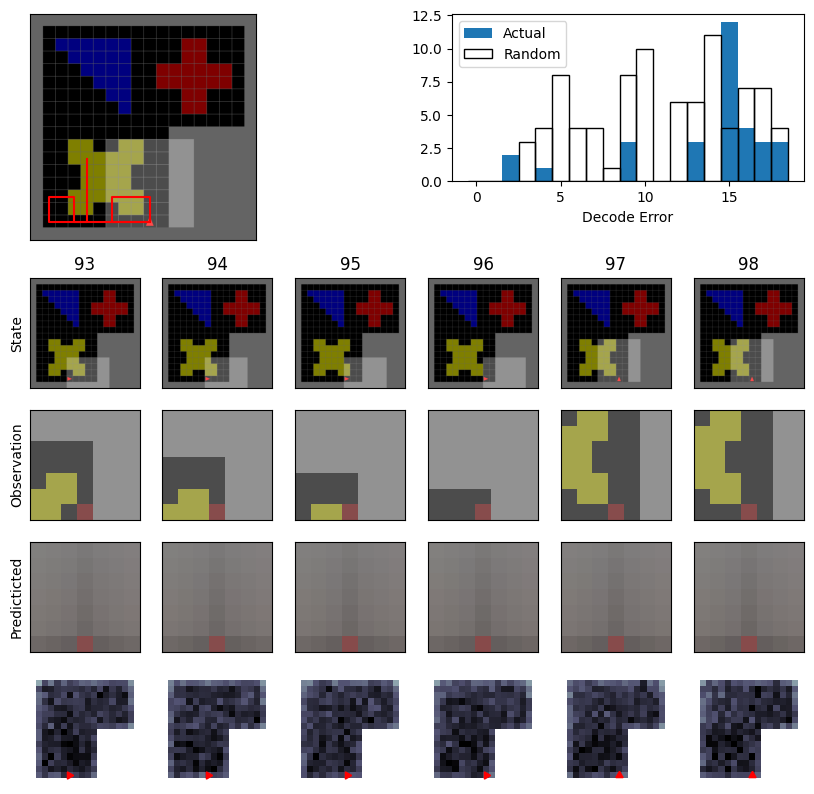

0.002
Training Decoder on cuda...
loss: 5.783056 [    0\ 5000]
loss: 4.852071 [  500\ 5000]
loss: 4.602410 [ 1000\ 5000]
loss: 4.387165 [ 1500\ 5000]
loss: 4.213124 [ 2000\ 5000]
loss: 4.066998 [ 2500\ 5000]
loss: 3.946550 [ 3000\ 5000]
loss: 3.857224 [ 3500\ 5000]
loss: 3.767865 [ 4000\ 5000]
loss: 3.696612 [ 4500\ 5000]
loss: 3.635640 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


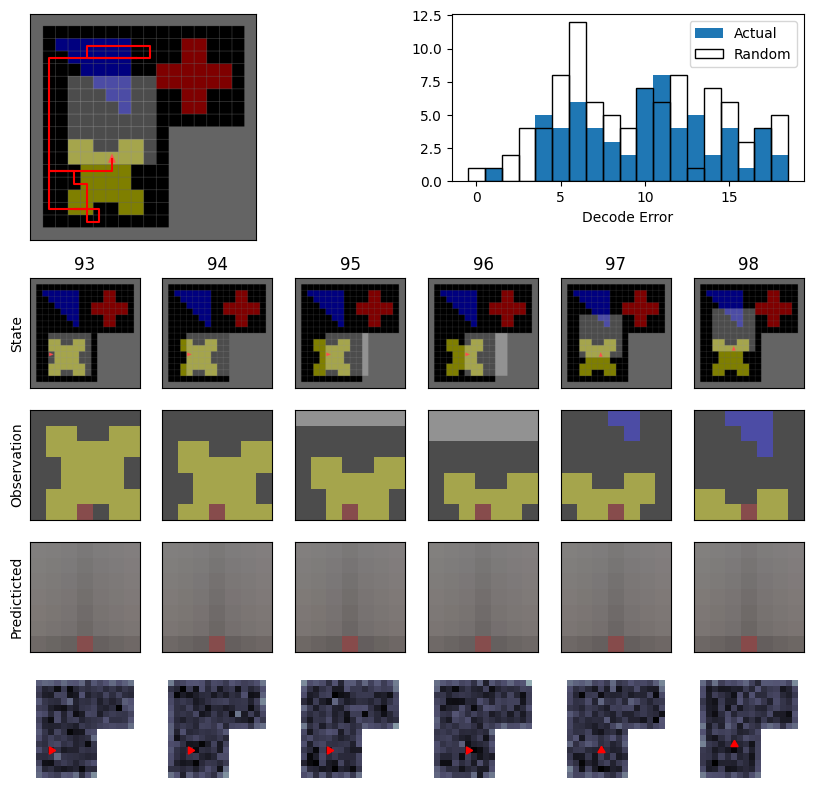

0.002
Training Decoder on cuda...
loss: 5.781318 [    0\ 5000]
loss: 4.810756 [  500\ 5000]
loss: 4.554135 [ 1000\ 5000]
loss: 4.354084 [ 1500\ 5000]
loss: 4.178779 [ 2000\ 5000]
loss: 4.036367 [ 2500\ 5000]
loss: 3.911964 [ 3000\ 5000]
loss: 3.821768 [ 3500\ 5000]
loss: 3.734828 [ 4000\ 5000]
loss: 3.670695 [ 4500\ 5000]
loss: 3.614633 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


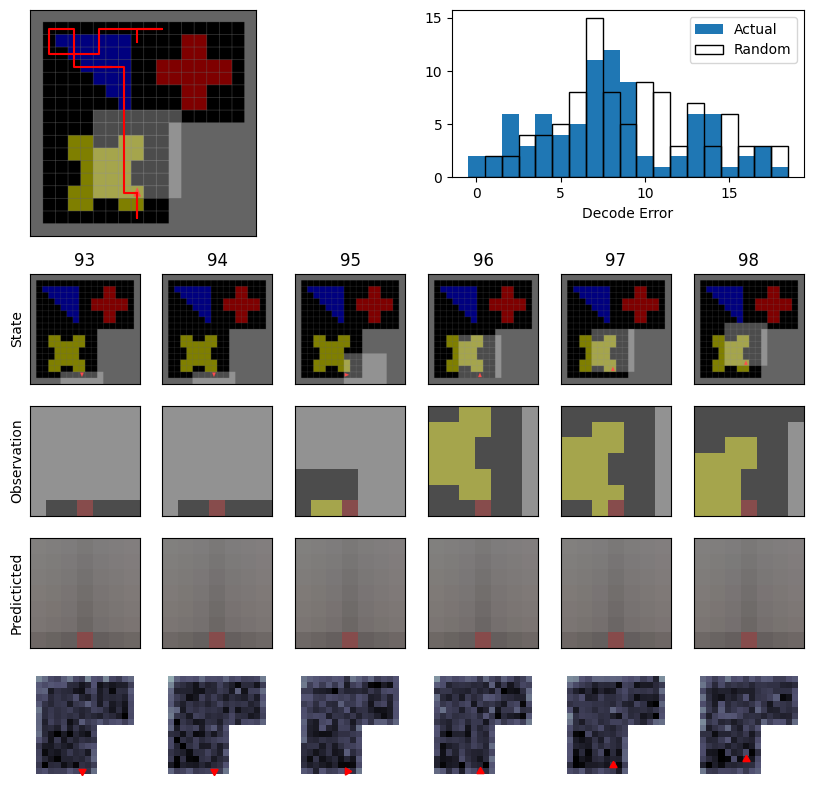

0.002
Training Decoder on cuda...
loss: 5.780284 [    0\ 5000]
loss: 4.827404 [  500\ 5000]
loss: 4.583817 [ 1000\ 5000]
loss: 4.377457 [ 1500\ 5000]
loss: 4.197953 [ 2000\ 5000]
loss: 4.047128 [ 2500\ 5000]
loss: 3.938621 [ 3000\ 5000]
loss: 3.832714 [ 3500\ 5000]
loss: 3.752644 [ 4000\ 5000]
loss: 3.682304 [ 4500\ 5000]
loss: 3.616164 [ 4999\ 5000]
Training Complete. Back to the cpu


/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.conspecific to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.conspecific` for environment variables or `env.get_wrapper_attr('conspecific')` that will search the reminding wrappers.
  logger.warn(
/gpfs/radev/home/mc3863/.conda/envs/prnn_tutorial/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_frame to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_frame` for environment variables or `env.get_wrapper_attr('get_frame')` that will search the reminding wrappers.
  logger.warn(


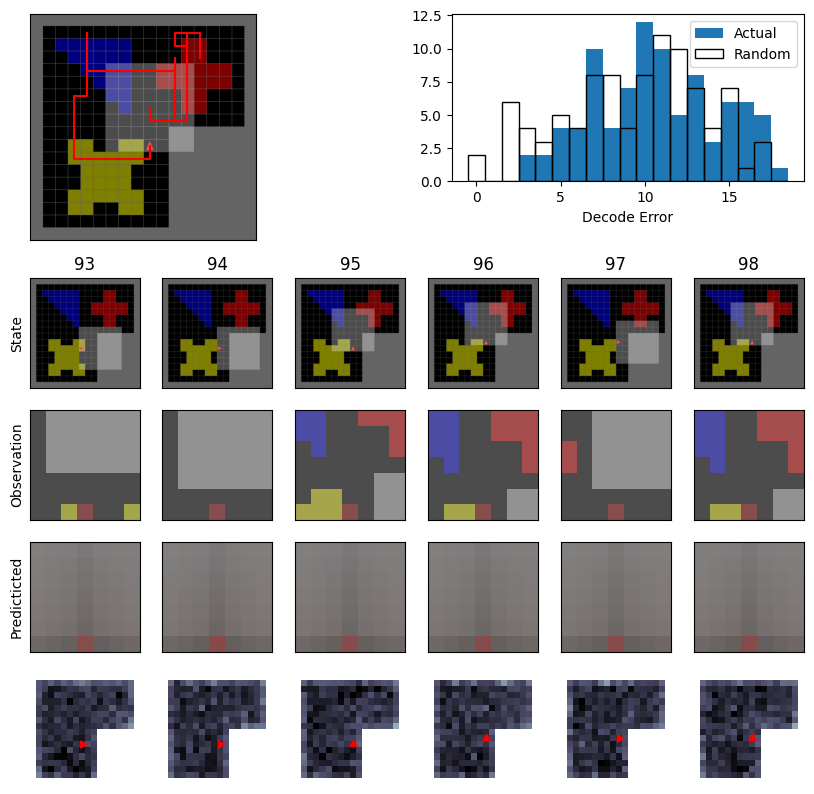

In [21]:
eg_nets = []
for i in range(6): 
    net = pNet.PredictiveNet.loadNet(f'weight_decay_panel/Masked-{i}-s6')
    eg_nets.append(net)
    print(net.trainArgs.eg_weight_decay)
for net in eg_nets:
  print(net.trainArgs.eg_lr)
  place_fields, SI, decoder = net.calculateSpatialRepresentation(env,agent,
                                              trainDecoder=True)
  net.calculateDecodingPerformance(env,agent,decoder,
                                              savename=None, savefolder=None,
                                            trajectoryWindow=100,
                                            timesteps=100)

(-0.25, 0.25)

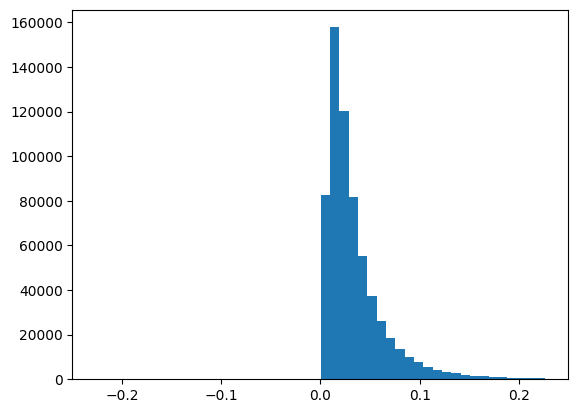

In [46]:
plt.hist(net2.pRNN.W.detach().cpu().numpy().flatten(), bins = 100)
plt.xlim(-0.25,.25)

In [39]:
net.pRNN.W.detach().cpu().numpy().flatten()

array([2.6130626e-01, 1.5297797e-02, 9.8125171e-04, ..., 1.9397731e-03,
       1.0120461e-02, 1.7417312e+00], dtype=float32)

(0.0, 1000.0)

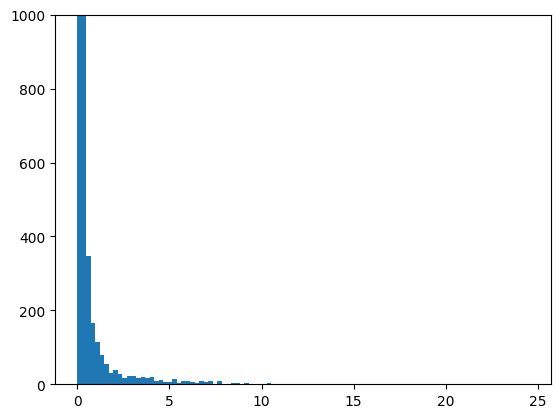

In [51]:
plt.hist(net.pRNN.W.detach().cpu().numpy().flatten(), bins = 100)
#plt.xlim(-0.25,.25)
plt.ylim([0,1000])

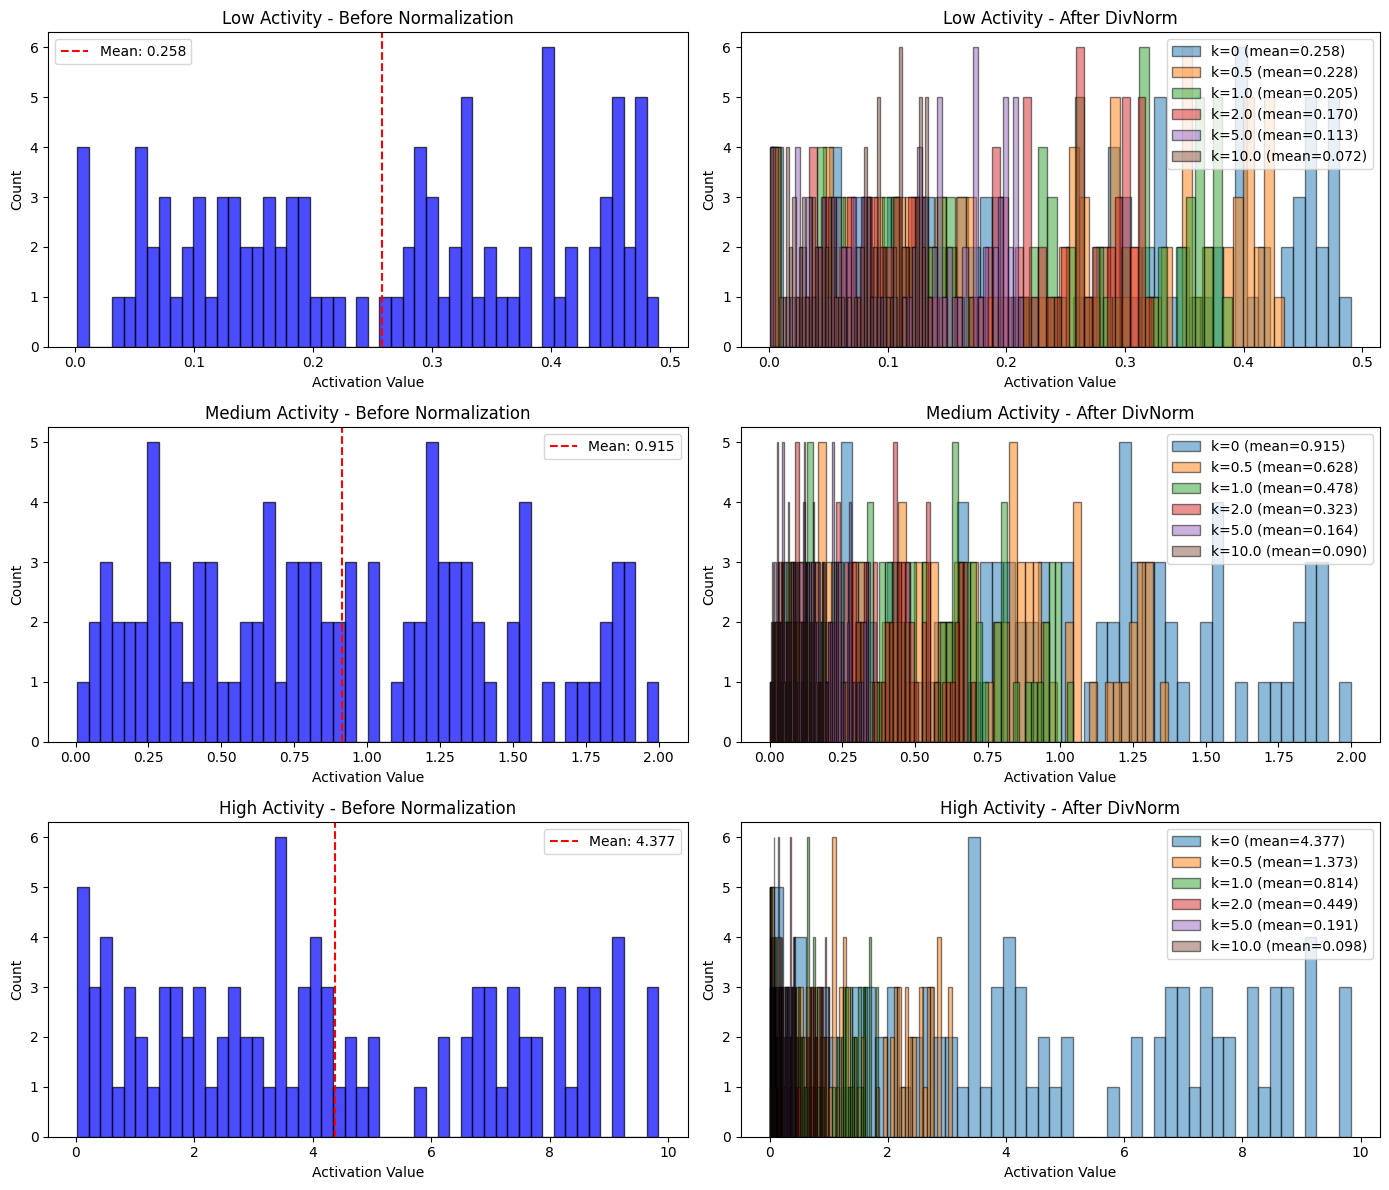


DIVISIVE NORMALIZATION STATISTICS

Low Activity:
  Original - Mean: 0.2579, Std: 0.1473
  k=  0.0 - Mean: 0.2579, Std: 0.1473, Divisor: 1.0000
  k=  0.5 - Mean: 0.2285, Std: 0.1305, Divisor: 1.1290
  k=  1.0 - Mean: 0.2050, Std: 0.1171, Divisor: 1.2579
  k=  2.0 - Mean: 0.1701, Std: 0.0972, Divisor: 1.5158
  k=  5.0 - Mean: 0.1126, Std: 0.0643, Divisor: 2.2896
  k= 10.0 - Mean: 0.0721, Std: 0.0411, Divisor: 3.5791

Medium Activity:
  Original - Mean: 0.9149, Std: 0.5527
  k=  0.0 - Mean: 0.9149, Std: 0.5527, Divisor: 1.0000
  k=  0.5 - Mean: 0.6278, Std: 0.3792, Divisor: 1.4575
  k=  1.0 - Mean: 0.4778, Std: 0.2886, Divisor: 1.9149
  k=  2.0 - Mean: 0.3233, Std: 0.1953, Divisor: 2.8299
  k=  5.0 - Mean: 0.1641, Std: 0.0992, Divisor: 5.5746
  k= 10.0 - Mean: 0.0901, Std: 0.0545, Divisor: 10.1493

High Activity:
  Original - Mean: 4.3770, Std: 2.9786
  k=  0.0 - Mean: 4.3770, Std: 2.9786, Divisor: 1.0000
  k=  0.5 - Mean: 1.3727, Std: 0.9342, Divisor: 3.1885
  k=  1.0 - Mean: 0.8140, St

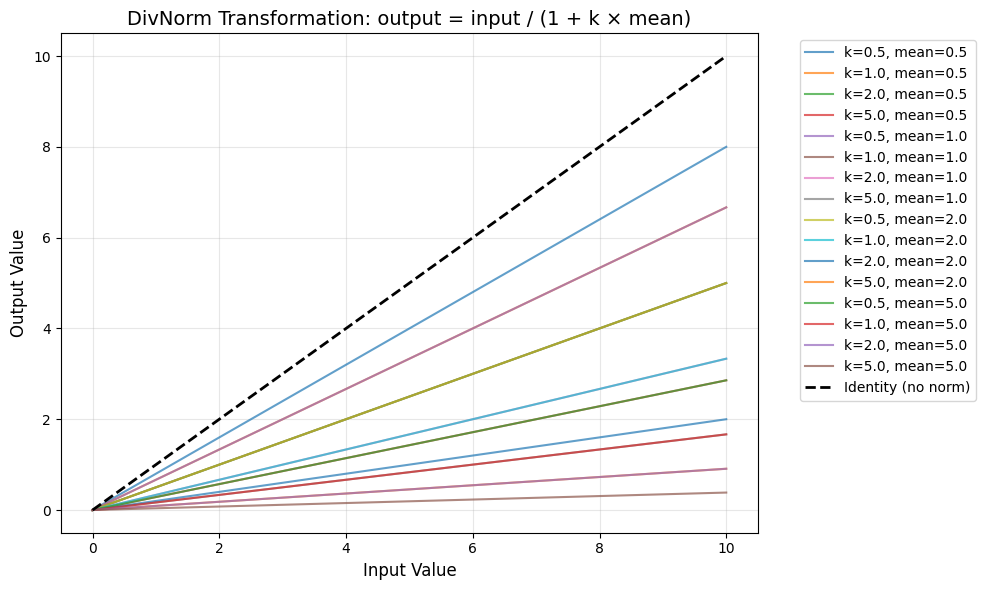

In [29]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

class DivNorm(nn.Module):
    def __init__(self, normalized_shape, k_div=1.0):
        super(DivNorm, self).__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = torch.Size(normalized_shape)
        self.k_div = k_div
        self.W_ie = None  # Ignore weight matrix
        
    def compute_divnorm_stats(self, input):
        if self.W_ie is not None:
            weighted_activity = torch.mm(input, self.W_ie.t())
        else:
            weighted_activity = input.mean(-1, keepdim=True)
        return weighted_activity
    
    def forward(self, input):
        weighted_activity = self.compute_divnorm_stats(input)
        return input / (1 + self.k_div * weighted_activity)

# Test with different k values
k_values = [0, 0.5, 1.0, 2.0, 5.0, 10.0]
hidden_size = 100

# Create sample input with varying activity levels
np.random.seed(42)
torch.manual_seed(42)

# Three test cases: low, medium, high activity
test_inputs = [
    torch.rand(1, hidden_size) * 0.5,      # Low activity (0-0.5)
    torch.rand(1, hidden_size) * 2.0,      # Medium activity (0-2.0)
    torch.rand(1, hidden_size) * 10.0,     # High activity (0-10.0)
]
test_names = ['Low Activity', 'Medium Activity', 'High Activity']

# Plot
fig, axes = plt.subplots(len(test_inputs), 2, figsize=(14, 4*len(test_inputs)))

for i, (x_input, name) in enumerate(zip(test_inputs, test_names)):
    
    # Plot original input
    ax1 = axes[i, 0] if len(test_inputs) > 1 else axes[0]
    ax1.hist(x_input.numpy().flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax1.set_title(f'{name} - Before Normalization')
    ax1.set_xlabel('Activation Value')
    ax1.set_ylabel('Count')
    ax1.axvline(x_input.mean().item(), color='red', linestyle='--', 
                label=f'Mean: {x_input.mean().item():.3f}')
    ax1.legend()
    
    # Plot after normalization with different k values
    ax2 = axes[i, 1] if len(test_inputs) > 1 else axes[1]
    
    for k in k_values:
        divnorm = DivNorm(hidden_size, k_div=k)
        x_normalized = divnorm(x_input)
        
        ax2.hist(x_normalized.numpy().flatten(), bins=50, alpha=0.5, 
                label=f'k={k} (mean={x_normalized.mean():.3f})', edgecolor='black')
    
    ax2.set_title(f'{name} - After DivNorm')
    ax2.set_xlabel('Activation Value')
    ax2.set_ylabel('Count')
    ax2.legend()

plt.tight_layout()
plt.savefig('divnorm_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*80)
print("DIVISIVE NORMALIZATION STATISTICS")
print("="*80)

for name, x_input in zip(test_names, test_inputs):
    print(f"\n{name}:")
    print(f"  Original - Mean: {x_input.mean():.4f}, Std: {x_input.std():.4f}")
    
    for k in k_values:
        divnorm = DivNorm(hidden_size, k_div=k)
        x_normalized = divnorm(x_input)
        mean_act = x_input.mean(-1, keepdim=True)
        divisor = 1 + k * mean_act
        
        print(f"  k={k:5.1f} - Mean: {x_normalized.mean():.4f}, "
              f"Std: {x_normalized.std():.4f}, "
              f"Divisor: {divisor.item():.4f}")

# Visualize the transformation function
print("\n" + "="*80)
print("TRANSFORMATION FUNCTION: output = input / (1 + k * mean(input))")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x_range = np.linspace(0, 10, 1000)

for mean_val in [0.5, 1.0, 2.0, 5.0]:
    for k in [0.5, 1.0, 2.0, 5.0]:
        y = x_range / (1 + k * mean_val)
        ax.plot(x_range, y, label=f'k={k}, mean={mean_val}', alpha=0.7)

ax.plot(x_range, x_range, 'k--', label='Identity (no norm)', linewidth=2)
ax.set_xlabel('Input Value', fontsize=12)
ax.set_ylabel('Output Value', fontsize=12)
ax.set_title('DivNorm Transformation: output = input / (1 + k × mean)', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('divnorm_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

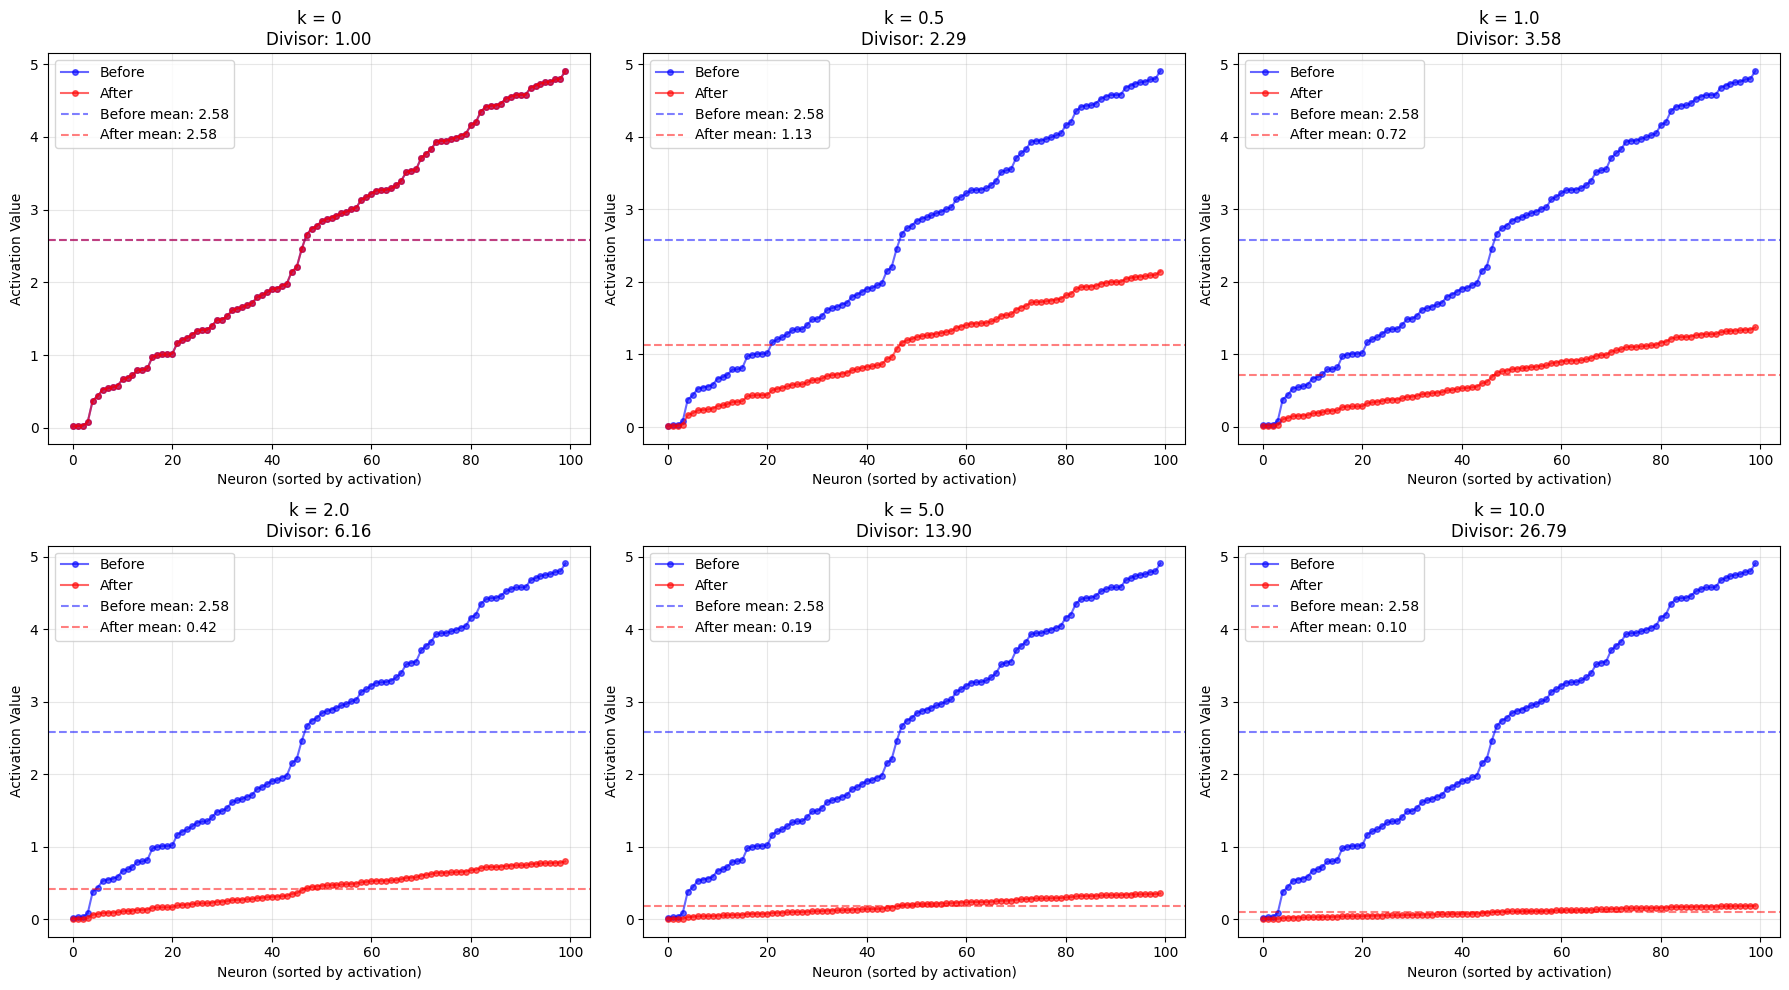

In [30]:
class DivNorm(nn.Module):
    def __init__(self, normalized_shape, k_div=1.0):
        super(DivNorm, self).__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = torch.Size(normalized_shape)
        self.k_div = k_div
        self.W_ie = None
        
    def compute_divnorm_stats(self, input):
        if self.W_ie is not None:
            weighted_activity = torch.mm(input, self.W_ie.t())
        else:
            weighted_activity = input.mean(-1, keepdim=True)
        return weighted_activity
    
    def forward(self, input):
        weighted_activity = self.compute_divnorm_stats(input)
        return input / (1 + self.k_div * weighted_activity)

# Test parameters
k_values = [0, 0.5, 1.0, 2.0, 5.0, 10.0]
hidden_size = 100

# Create sample input with diverse activity
torch.manual_seed(42)
x_input = torch.rand(1, hidden_size) * 5.0  # Activity between 0-5

# Sort for better visualization
x_sorted, sort_idx = torch.sort(x_input.squeeze())

# ============================================================================
# VISUALIZATION 1: Before/After Line Plot for Each Neuron
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    
    divnorm = DivNorm(hidden_size, k_div=k)
    x_normalized = divnorm(x_input)
    x_norm_sorted = x_normalized.squeeze()[sort_idx]
    
    neuron_ids = np.arange(hidden_size)
    
    # Plot before and after
    ax.plot(neuron_ids, x_sorted.numpy(), 'o-', color='blue', 
            alpha=0.6, label='Before', markersize=4)
    ax.plot(neuron_ids, x_norm_sorted.numpy(), 'o-', color='red', 
            alpha=0.6, label='After', markersize=4)
    
    # Add mean lines
    ax.axhline(x_input.mean().item(), color='blue', linestyle='--', 
               alpha=0.5, label=f'Before mean: {x_input.mean():.2f}')
    ax.axhline(x_normalized.mean().item(), color='red', linestyle='--', 
               alpha=0.5, label=f'After mean: {x_normalized.mean():.2f}')
    
    ax.set_xlabel('Neuron (sorted by activation)')
    ax.set_ylabel('Activation Value')
    ax.set_title(f'k = {k}\nDivisor: {1 + k * x_input.mean():.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('divnorm_individual_neurons.png', dpi=150, bbox_inches='tight')
plt.show()

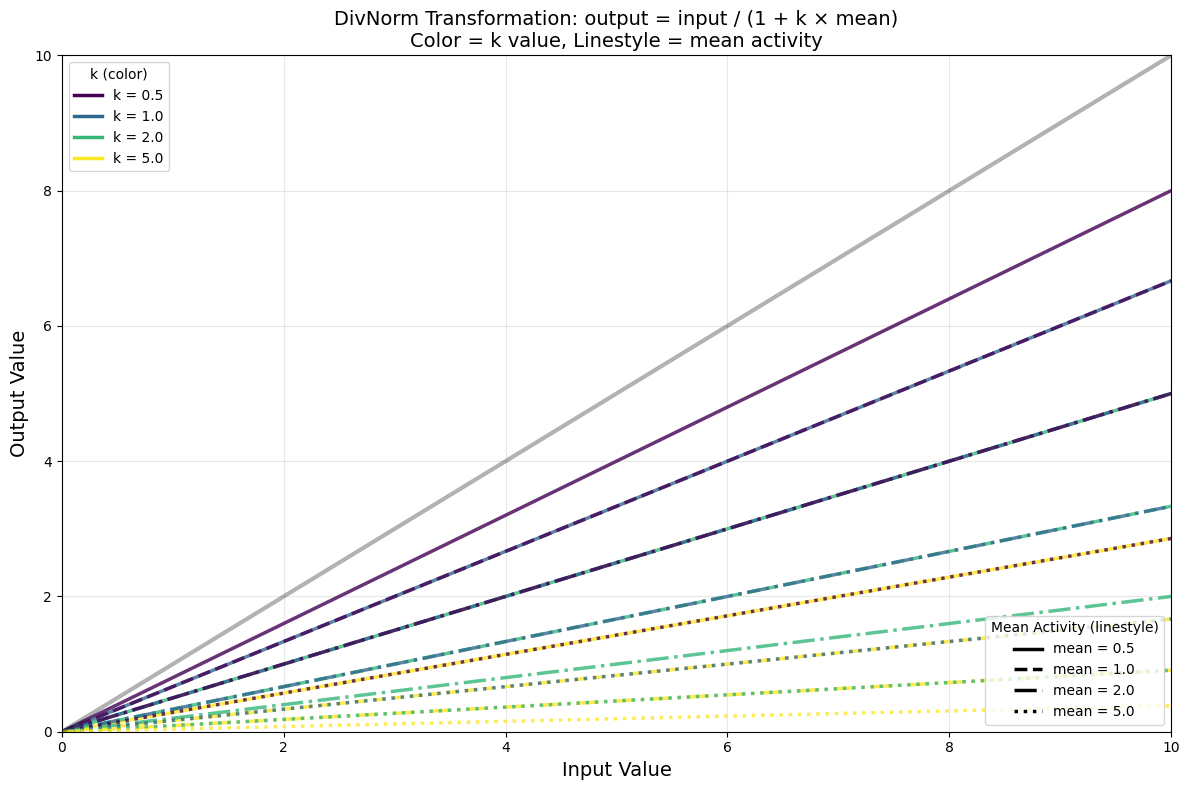


PLOT INTERPRETATION GUIDE

COLORS (k values):
  k = 0.5: RGB (0.267004, 0.004874, 0.329415)
  k = 1.0: RGB (0.190631, 0.407061, 0.556089)
  k = 2.0: RGB (0.20803, 0.718701, 0.472873)
  k = 5.0: RGB (0.993248, 0.906157, 0.143936)

LINE STYLES (mean values):
  mean = 0.5: -
  mean = 1.0: --
  mean = 2.0: -.
  mean = 5.0: :

KEY INSIGHTS:
  - Higher k (brighter color) → stronger compression
  - Higher mean (different line style) → stronger compression
  - Effect is multiplicative: divisor = 1 + k × mean


In [31]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

x_range = np.linspace(0, 10, 1000)

# Define line styles for different means
mean_vals = [0.5, 1.0, 2.0, 5.0]
linestyles = ['-', '--', '-.', ':']
linestyle_dict = dict(zip(mean_vals, linestyles))

# Define colors for different k values
k_vals = [0.5, 1.0, 2.0, 5.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(k_vals)))
color_dict = dict(zip(k_vals, colors))

# Plot all combinations
for mean_val in mean_vals:
    for k in k_vals:
        y = x_range / (1 + k * mean_val)
        ax.plot(x_range, y, 
                linestyle=linestyle_dict[mean_val],
                color=color_dict[k],
                linewidth=2.5,
                alpha=0.8)

# Create custom legends
from matplotlib.lines import Line2D

# Legend for k values (colors)
k_legend_elements = [Line2D([0], [0], color=color_dict[k], linewidth=2.5, 
                            label=f'k = {k}') for k in k_vals]

# Legend for mean values (line styles)
mean_legend_elements = [Line2D([0], [0], color='black', linestyle=linestyle_dict[mean], 
                               linewidth=2.5, label=f'mean = {mean}') 
                        for mean in mean_vals]

# Add identity line
ax.plot(x_range, x_range, 'k-', linewidth=3, alpha=0.3, label='Identity (no norm)')

# Create two legends
legend1 = ax.legend(handles=k_legend_elements, title='k (color)', 
                    loc='upper left', fontsize=10)
ax.add_artist(legend1)  # Add first legend back

legend2 = ax.legend(handles=mean_legend_elements, title='Mean Activity (linestyle)', 
                    loc='lower right', fontsize=10)

ax.set_xlabel('Input Value', fontsize=14)
ax.set_ylabel('Output Value', fontsize=14)
ax.set_title('DivNorm Transformation: output = input / (1 + k × mean)\n' + 
             'Color = k value, Linestyle = mean activity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])

plt.tight_layout()
plt.savefig('divnorm_transformation_styled.png', dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation guide
print("\n" + "="*80)
print("PLOT INTERPRETATION GUIDE")
print("="*80)
print("\nCOLORS (k values):")
for k, color in color_dict.items():
    print(f"  k = {k}: RGB {tuple(color[:3])}")
    
print("\nLINE STYLES (mean values):")
for mean, style in linestyle_dict.items():
    print(f"  mean = {mean}: {style}")
    
print("\nKEY INSIGHTS:")
print("  - Higher k (brighter color) → stronger compression")
print("  - Higher mean (different line style) → stronger compression")
print("  - Effect is multiplicative: divisor = 1 + k × mean")